In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer  
from sklearn.preprocessing import LabelEncoder



train_c=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_c=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

In [3]:
train=train_c.copy()
test=test_c.copy()

print('train shape:',train.shape)
print('test.shape:',test.shape)

train shape: (198000, 15)
test.shape: (102000, 14)


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [5]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


**MILESTONE 1**

In [6]:
#What is the shape of the training dataset
print("train shape:",train.shape)

#How many columns are present in the test dataset?
print("test shape:",test.shape)
print("columns in test dataset:",test.shape[1] )

#How many columns in the training dataset have object data type
print('training dataset with obj data type',train.select_dtypes(include='object').shape)

#How many numerical columns are present in the training dataset?
print("training dataset with num data type",train.select_dtypes(include='number').shape)

#Which of the following columns is of boolean type?
print("training dataset with num data type",train.select_dtypes(include='boolean').columns)

#How many distinct target classes are present in the dataset?
print('no. of distinct target classes are present in the dataset',train['label'].nunique())
print('distinct target classes are present in the dataset',train['label'].unique())

#What is the median number of upvotes per comment?
print('median of upvotes:',train['upvote'].median())


train shape: (198000, 15)
test shape: (102000, 14)
columns in test dataset: 14
training dataset with obj data type (198000, 5)
training dataset with num data type (198000, 9)
training dataset with num data type Index(['disability'], dtype='object')
no. of distinct target classes are present in the dataset 4
distinct target classes are present in the dataset [2 0 1 3]
median of upvotes: 1.0


In [7]:
train.describe(include='all')

#50th percentile is the median or
#train['upvote'].median()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
count,198000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,52577,52577,52577,198000,197999,198000.000000
unique,197996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,8,5,2,197842,NaN
top,2022-05-06 20:47:06.726636+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,none,none,False,Exactly..,NaN
freq,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39682,38249,36161,195257,8,NaN
mean,NaN,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,NaN,NaN,NaN,NaN,NaN,0.793965
std,NaN,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,NaN,NaN,NaN,NaN,NaN,0.979808
min,NaN,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,NaN,NaN,NaN,NaN,NaN,2.000000


In [8]:
#percentage of the dataset approximately belongs to label
label_count=train['label'].value_counts(normalize=True)*100
label_count
#normalise=True converts count into proportions 

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64

null count:

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


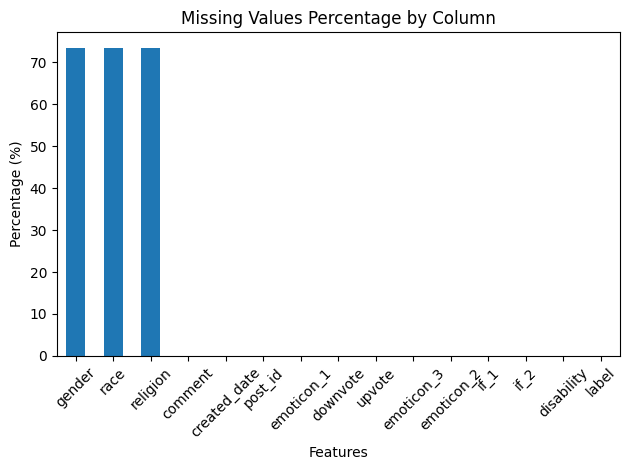

In [9]:
#checking missing values in train dataset
print("null count:"+'\n')
print(train.isna().sum())
#print("missing % of data"+'\n')
missing_pct=(train.isna().sum()/(train.shape[0])*100)
missing_count=train.isna().sum()
missing_pct 
missing_pct.sort_values(ascending=False).plot(kind='bar')
plt.title("Missing Values Percentage by Column")
plt.ylabel("Percentage (%)")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




In [10]:
train.loc[train['comment'].isna()]

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
99535,2024-04-18 06:40:48.161601+00:00,31,0,0,0,1,0,4,4,none,none,none,False,NaN,0


In [11]:
train= train.dropna(subset=['comment']) 
#dropping will not introduce bias , it only 1 out all the rows in comment 


In [12]:
f=['post_id','label','emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','race','religion','gender','disability']
for i in f:
    print(i,train[i].unique(),"unique values present =",train[i].nunique(),'\n')

post_id [ 73  39  31  72  71 120  40 111  64 123  61 105  84 118  76  24  91  85
 102  70  74  77  66  93 100  87  83 103 101 108 115  79  89  75 104  90
  95  96  67 129  82  50  43  42 109  88 125  86  20 113  65 110] unique values present = 52 

label [2 0 1 3] unique values present = 4 

emoticon_1 [ 0  1 15  2  3  4  5 11  6  7  8 24 12 17 14 13  9 10 20 16 25 18 21 19
 23 36 22 28 27 33 30 46 32 47 31 39] unique values present = 36 

emoticon_2 [ 0  1  2  4  3  5  8  6 11  7] unique values present = 10 

emoticon_3 [ 0  1  2  4  3  6  5 10  7 11  9 14 17 13  8 12] unique values present = 16 

upvote [  0   6   5   1   2   3   4  11  14  10  31  30  15   7   8  13  70   9
  12  36  22  71  19  55  16  18  17  29  24  20  28  23  32  21  26  50
  25  61  35  43  33  27  39  58  38  40  65  34  91  51  85  98  57  74
  78  56  68  42  44  54  41  48  62  67  37 123  46  52  45  64  53  72
 140 166  59  47 124 116  69  60  49  88 131  75  63 109  80  99  82 141
  87  76  92  73 159  

In [13]:
missing_rows=['race','religion','gender']
print(train[train[missing_rows].isna().all(axis=1)].shape)
#prints shape of those rows which has null values in all these 3 columns 

for e in missing_rows:
    print(e,train[e].unique())
    train[e].fillna('unknown', inplace=True) #replacing nan with unknown
    print(e, train[e].unique())



(145423, 15)
race [nan 'none' 'white' 'other' 'asian' 'black' 'latino']
race ['unknown' 'none' 'white' 'other' 'asian' 'black' 'latino']
religion [nan 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'
 'buddhist']
religion ['unknown' 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'
 'buddhist']
gender [nan 'none' 'male' 'female' 'transgender' 'other']
gender ['unknown' 'none' 'male' 'female' 'transgender' 'other']


/tmp/ipykernel_17/2264582669.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[e].fillna('unknown', inplace=True) #replacing nan with unknown


In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197999 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  197999 non-null  object
 1   post_id       197999 non-null  int64 
 2   emoticon_1    197999 non-null  int64 
 3   emoticon_2    197999 non-null  int64 
 4   emoticon_3    197999 non-null  int64 
 5   upvote        197999 non-null  int64 
 6   downvote      197999 non-null  int64 
 7   if_1          197999 non-null  int64 
 8   if_2          197999 non-null  int64 
 9   race          197999 non-null  object
 10  religion      197999 non-null  object
 11  gender        197999 non-null  object
 12  disability    197999 non-null  bool  
 13  comment       197999 non-null  object
 14  label         197999 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 22.8+ MB


**EDA-target and numerical attributes**

In [15]:
'''import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.<plot_type>(x=..., y=..., data=...)

plt.xlabel("...")
plt.ylabel("...")
plt.title("...")
plt.show()'''

'import matplotlib.pyplot as plt\nimport seaborn as sns\n\nplt.figure(figsize=(6,4))\n\nsns.<plot_type>(x=..., y=..., data=...)\n\nplt.xlabel("...")\nplt.ylabel("...")\nplt.title("...")\nplt.show()'

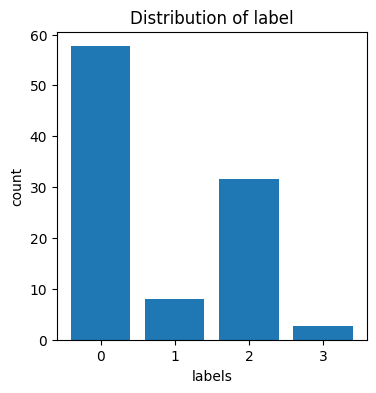

In [16]:
#Analysing label
plt.figure(figsize=(4,4))

plt.bar(label_count.index,label_count.values)
plt.title("Distribution of label")
plt.xlabel("labels")
plt.ylabel("count")
plt.show()

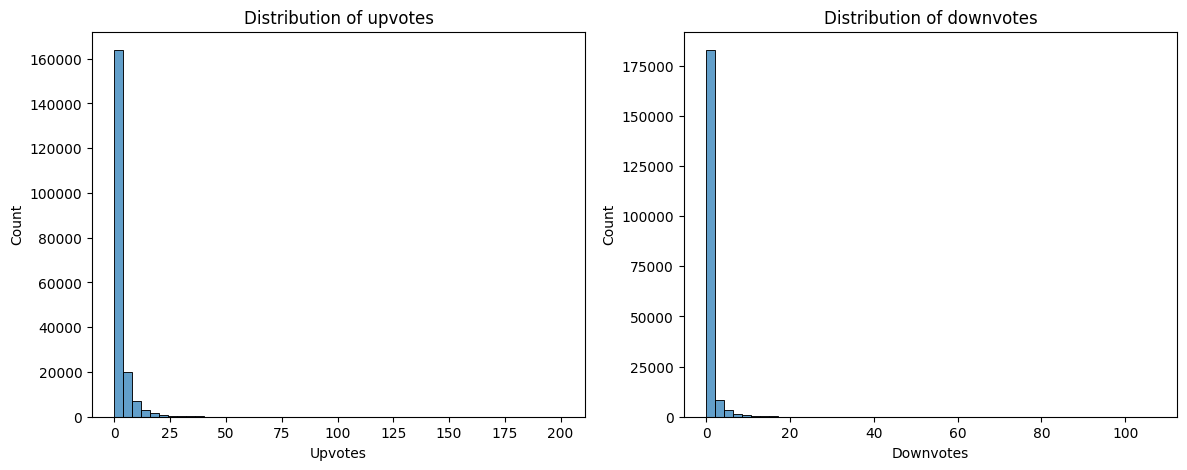

In [17]:
#Analyze upvote and downvote
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) #fig=entire fig 
sns.histplot(x='upvote',data=train,bins=50,alpha=0.7,ax=axes[0])
#axes[0].set_xscale('log')
axes[0].set(title="Distribution of upvotes",xlabel="Upvotes",ylabel="Count")

sns.histplot(x='downvote',data=train,bins=50,alpha=0.7,ax=axes[1])
axes[1].set(title="Distribution of downvotes",xlabel="Downvotes",ylabel="Count")
plt.show()


In [18]:
#correlation and heatmap
train.dtypes
num_col=train.select_dtypes(include=['number']).columns.tolist()
corr_matrix=train[num_col].corr()
corr_matrix


,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
post_id,1.000000,0.034566,0.012500,0.049620,-0.019457,0.065509,-0.000976,0.010234,0.022058
emoticon_1,0.034566,1.000000,0.092087,0.144864,0.128124,0.177236,-0.002624,-0.004116,-0.003220
emoticon_2,0.012500,0.092087,1.000000,0.140236,0.081579,0.169366,0.001741,0.003918,0.021596
emoticon_3,0.049620,0.144864,0.140236,1.000000,0.170662,0.371039,-0.000514,0.007191,0.027273
upvote,-0.019457,0.128124,0.081579,0.170662,1.000000,0.314556,-0.001654,-0.000674,0.040179
downvote,0.065509,0.177236,0.169366,0.371039,0.314556,1.000000,0.000354,0.006306,0.044906
if_1,-0.000976,-0.002624,0.001741,-0.000514,-0.001654,0.000354,1.000000,0.008174,0.007543
if_2,0.010234,-0.004116,0.003918,0.007191,-0.000674,0.006306,0.008174,1.000000,0.232901
label,0.022058,-0.003220,0.021596,0.027273,0.040179,0.044906,0.007543,0.232901,1.000000


<Axes: >

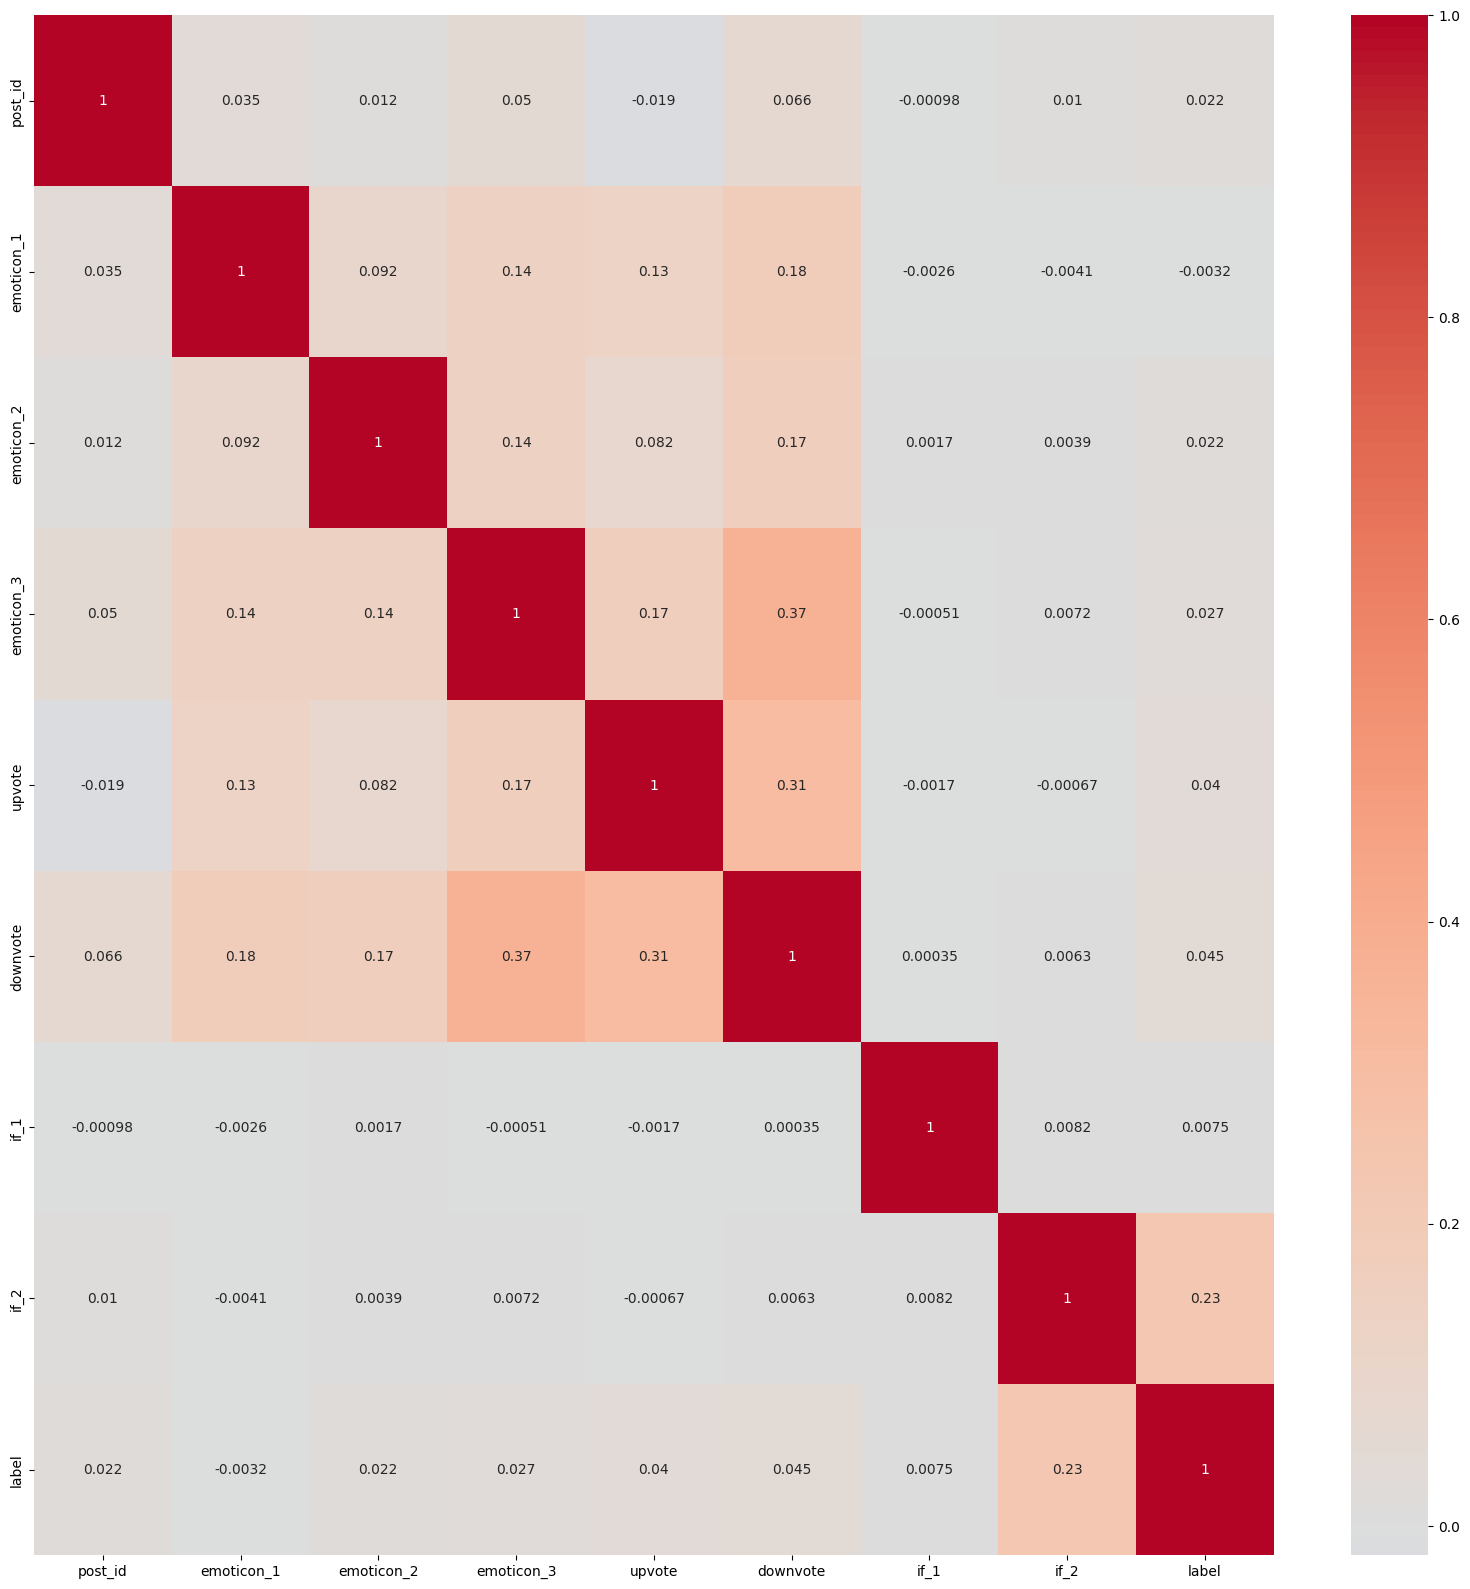

In [19]:
#heatmap
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',center=0)


In [20]:
#distribution of votes across label 

print("Mean upvotes/label\n",train.groupby('label')['upvote'].mean())
print('\n',"Median upvotes/label\n",train.groupby
      ('label')['upvote'].median())


Mean upvotes/label
 label
0    2.404845
1    2.850107
2    2.967825
3    2.035656
Name: upvote, dtype: float64

 Median upvotes/label
 label
0    1.0
1    1.0
2    1.0
3    1.0
Name: upvote, dtype: float64


In [21]:
print("Mean downvotes/label\n",train.groupby('label')['downvote'].mean())
print('\n',"Median downvotes/label",train.groupby('label')['downvote'].median())


Mean downvotes/label
 label
0    0.575299
1    0.802048
2    0.811723
3    0.514171
Name: downvote, dtype: float64

 Median downvotes/label label
0    0.0
1    0.0
2    0.0
3    0.0
Name: downvote, dtype: float64


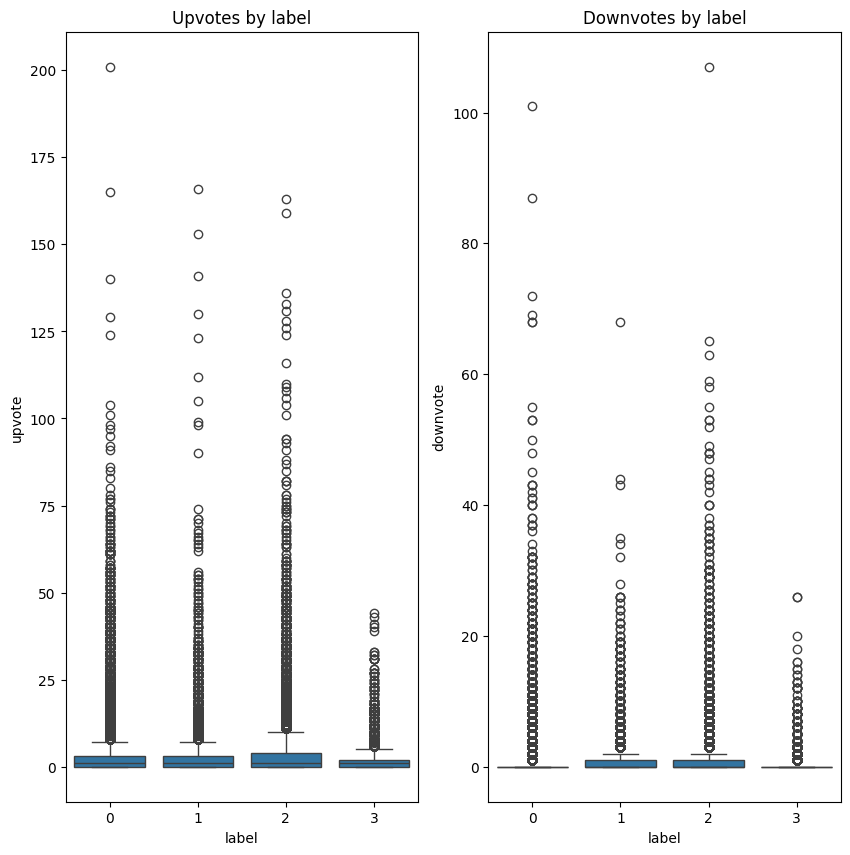

In [22]:
fig,ax=plt.subplots(1,2 ,figsize=(10,10))
sns.boxplot(x='label',y='upvote',data=train,ax=ax[0])
ax[0].set_title("Upvotes by label")

sns.boxplot(x='label',y='downvote',data=train,ax=ax[1])
ax[1].set_title("Downvotes by label")
plt.show()


In [23]:
#Analyze if_1 and if_2 (hidden features)
print("unique values in if_1 :",train['if_1'].nunique())
print("unique values in if_2 :",train['if_2'].nunique())

print('\nif_1 value counts:\n',train['if_1'].value_counts())

unique values in if_1 : 57
unique values in if_2 : 81

if_1 value counts:
 if_1
0       145423
4        31060
10       11849
6         6774
5         2691
7           70
9           45
11          32
12           2
1814         2
1545         2
1783         2
8            2
1551         2
249          1
1569         1
1800         1
1560         1
1263         1
1267         1
1258         1
1543         1
250          1
1815         1
1538         1
1585         1
1830         1
1277         1
1807         1
1810         1
1777         1
1848         1
1257         1
1548         1
1232         1
1583         1
1572         1
1576         1
1256         1
1566         1
1547         1
1825         1
1271         1
1838         1
1553         1
1846         1
1558         1
1557         1
1767         1
1819         1
1581         1
1254         1
1811         1
1860         1
1778         1
1827         1
1584         1
Name: count, dtype: int64


In [24]:
print('\nif_1 value counts:\n',train['if_2'].value_counts())


if_1 value counts:
 if_2
4       91725
10      80693
6       14558
5        6188
70        453
        ...  
1694        1
1527        1
1071        1
110         1
1171        1
Name: count, Length: 81, dtype: int64


**EDA-CATEGORICAL AND TEXT FEATURES**

In [25]:
train.dtypes

created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

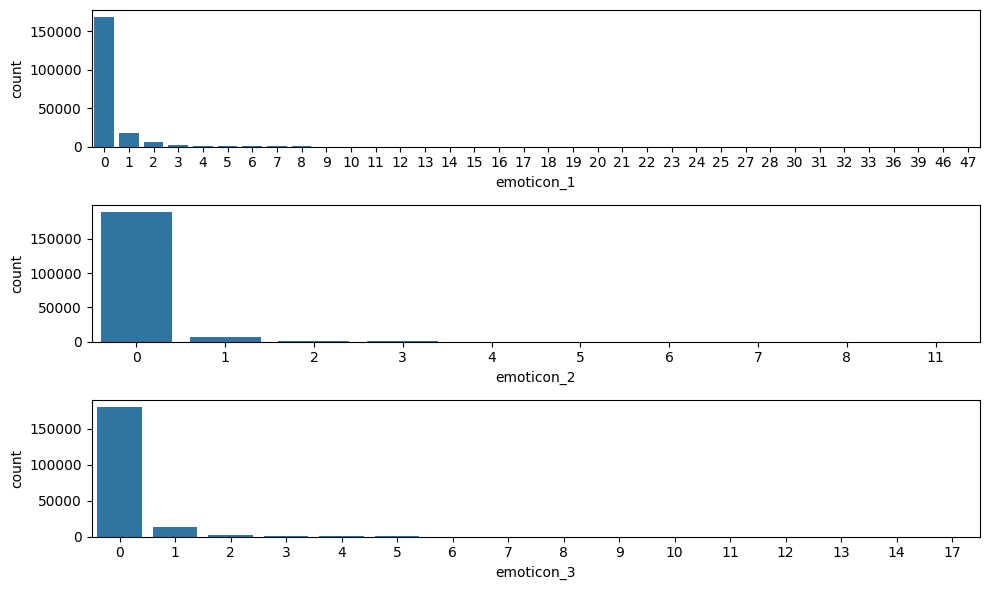

In [26]:
emo_col=['emoticon_1','emoticon_2','emoticon_3']

fig,ax=plt.subplots(3,1,figsize=(10,6))
for idx,x in enumerate(emo_col):
    sns.countplot(x=x,data=train,ax=ax[idx])
    ax[idx].set_xlabel(x)
plt.tight_layout()
plt.show()

In [27]:
#Analyze topic indicators (race, religion, gender, disability)
cat_col=['race','religion','gender','disability']
for c in cat_col:
    print(c,train[c].unique())
    print('\n',train[c].value_counts())
    print(f"\nnull count {c}")
    print(train[c].isna().sum(),'\n') #includes both nan and none

race ['unknown' 'none' 'white' 'other' 'asian' 'black' 'latino']

 race
unknown    145423
none        39681
white        5486
black        3869
other        1654
asian        1263
latino        623
Name: count, dtype: int64

null count race
0 

religion ['unknown' 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'
 'buddhist']

 religion
unknown      145423
none          38248
christian      7191
muslim         4930
jewish         1244
other           547
atheist         219
buddhist        100
hindu            97
Name: count, dtype: int64

null count religion
0 

gender ['unknown' 'none' 'male' 'female' 'transgender' 'other']

 gender
unknown        145423
none            36160
female           8037
male             7549
transgender       622
other             208
Name: count, dtype: int64

null count gender
0 

disability [False  True]

 disability
False    195256
True       2743
Name: count, dtype: int64

null count disability
0 



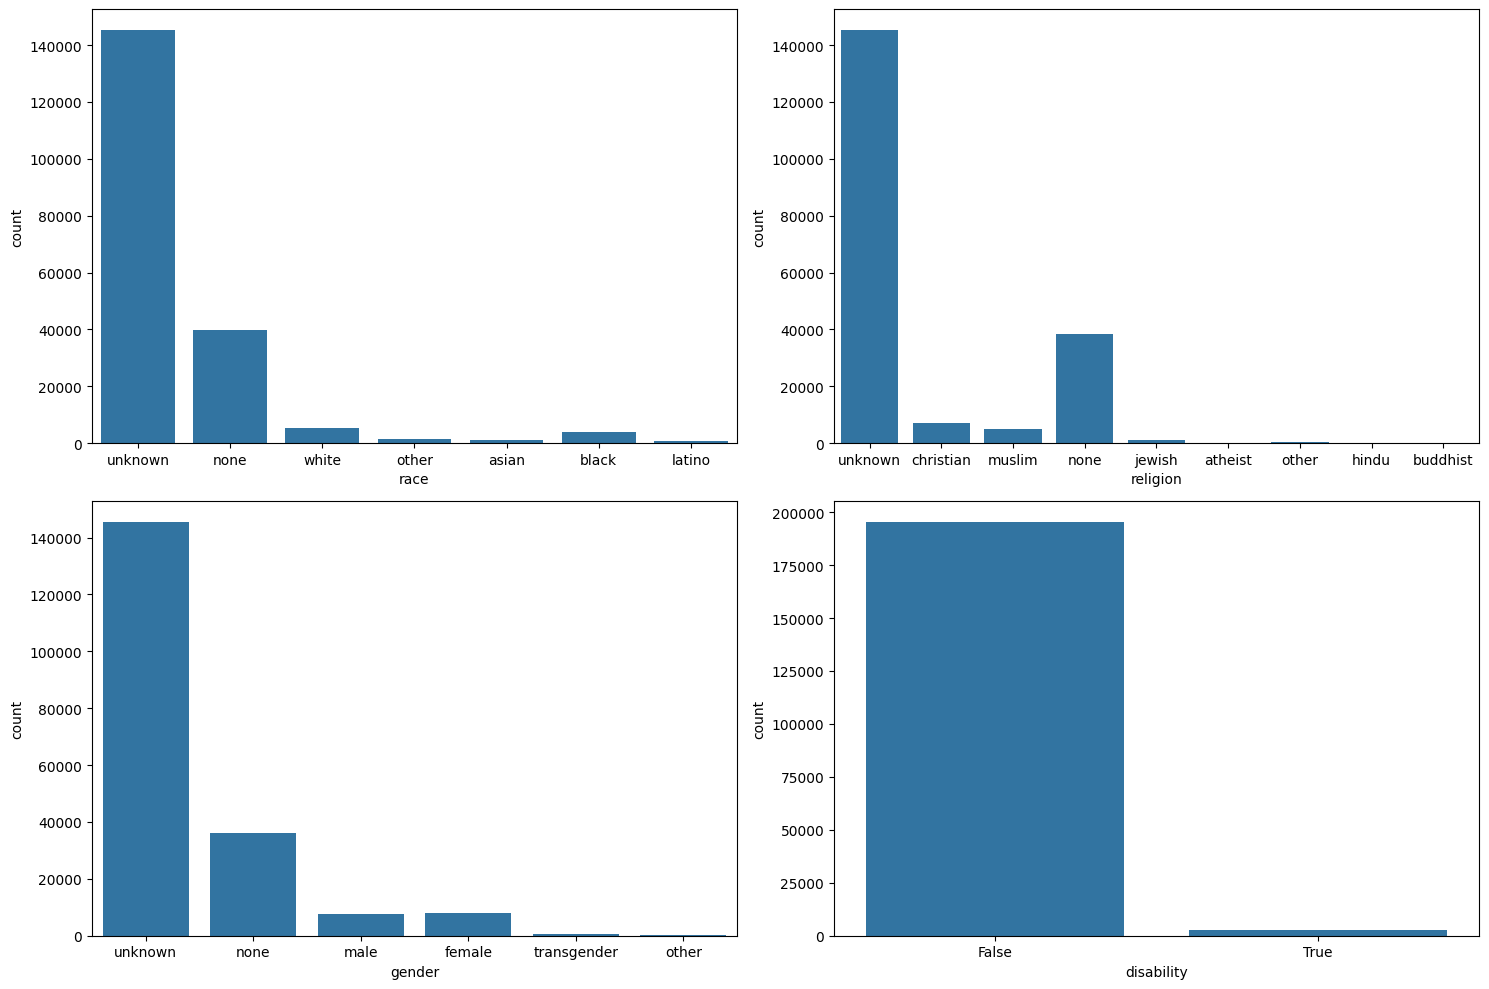

In [28]:
fig,ax=plt.subplots(2,2,figsize=(15,10))
ax=ax.ravel()
for i,c in enumerate (cat_col):
    sns.countplot(x=c,data=train,ax=ax[i])
    ax[i].set_xlabel(c)
plt.tight_layout()
plt.show()

In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197999 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  197999 non-null  object
 1   post_id       197999 non-null  int64 
 2   emoticon_1    197999 non-null  int64 
 3   emoticon_2    197999 non-null  int64 
 4   emoticon_3    197999 non-null  int64 
 5   upvote        197999 non-null  int64 
 6   downvote      197999 non-null  int64 
 7   if_1          197999 non-null  int64 
 8   if_2          197999 non-null  int64 
 9   race          197999 non-null  object
 10  religion      197999 non-null  object
 11  gender        197999 non-null  object
 12  disability    197999 non-null  bool  
 13  comment       197999 non-null  object
 14  label         197999 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 22.8+ MB


In [30]:
#text analysis- word count and comment length
def length(comm):
    if pd.isna(comm):
        return 0
    return len(comm)
    
train['comment_length']=train['comment'].apply(length) #extracts length of a comment/string(including punc/spaces/characters)
train['word_count']=train['comment'].apply(lambda x: len(str(x).split())) 
#converts ecah comment into a list of words and cal length of a list (i.e count of words in a comment)

print("Word Count Statistics")
display(train['word_count'].describe())

Word Count Statistics


count    197999.000000
mean         52.397249
std          45.770185
min           1.000000
25%          18.000000
50%          37.000000
75%          73.000000
max         315.000000
Name: word_count, dtype: float64

In [31]:
#cross-tab with labels (conditional analysis)
for c in cat_col:
    ct=pd.crosstab(train[c],train['label'],normalize='index')*100
    #normalize='index'-> row-wise normalization.Each row index is divided by its row total,computes p(label|category)
    display(ct) #display preserves the standard table format while print strips it away 

label,0,1,2,3
race,,,,
asian,45.130641,28.820269,24.148852,1.900238
black,15.714655,69.242698,14.344792,0.697855
latino,43.980738,32.102729,22.953451,0.963082
none,51.926615,15.468360,30.173131,2.431894
other,40.870617,29.564692,27.388150,2.176542
unknown,62.243249,1.863529,32.901260,2.991961
white,16.824645,60.845789,21.235873,1.093693


label,0,1,2,3
religion,,,,
atheist,38.812785,32.420091,26.027397,2.739726
buddhist,43.000000,39.000000,17.000000,1.000000
christian,48.115700,30.037547,20.831595,1.015158
hindu,51.546392,29.896907,17.525773,1.030928
jewish,27.974277,54.099678,16.881029,1.045016
muslim,19.574037,63.569980,14.847870,2.008114
none,48.428676,17.995712,31.185944,2.389667
other,33.272395,40.036563,24.680073,2.010969
unknown,62.243249,1.863529,32.901260,2.991961


label,0,1,2,3
gender,,,,
female,42.914023,24.449421,30.172950,2.463606
male,36.534640,28.374619,32.785799,2.304941
none,47.566372,24.043142,26.352323,2.038164
other,36.057692,37.980769,24.038462,1.923077
transgender,27.974277,52.733119,18.488746,0.803859
unknown,62.243249,1.863529,32.901260,2.991961


label,0,1,2,3
disability,,,,
False,58.031507,7.935224,31.263060,2.770209
True,31.425447,15.457528,50.929639,2.187386


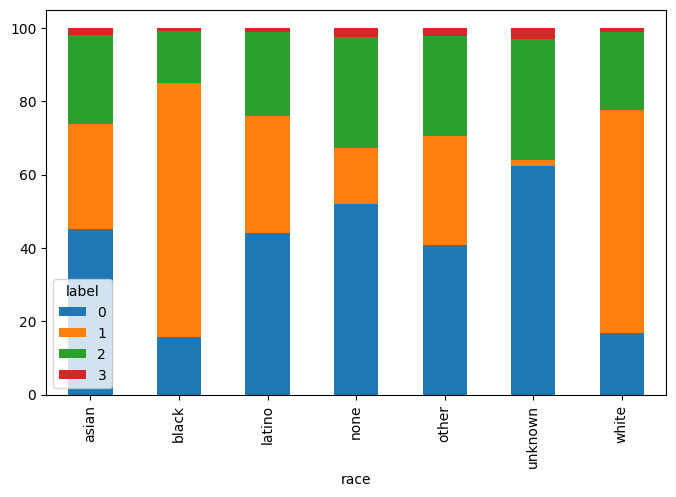

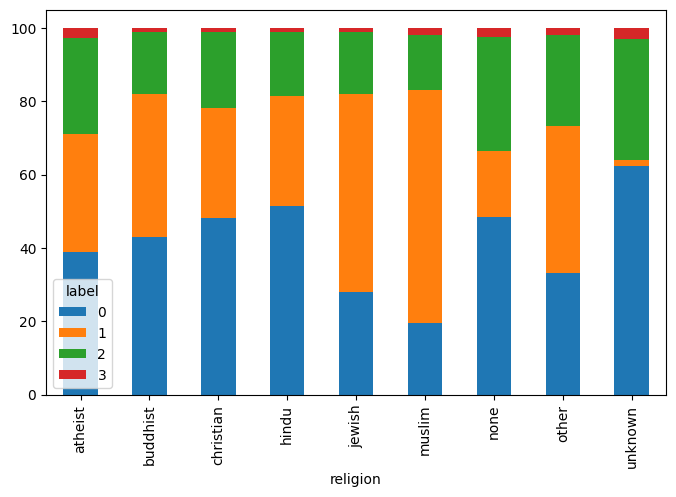

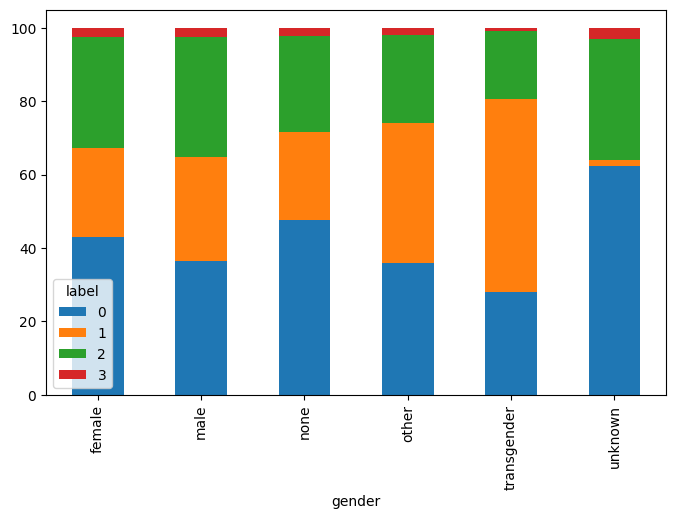

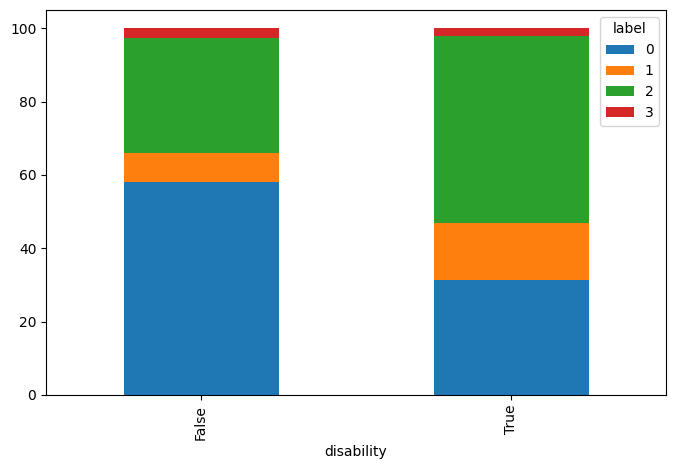

In [32]:
#cross-tab with labels (conditional analysis)
for c in cat_col:
    ct=pd.crosstab(train[c],train['label'],normalize='index')*100
    ct.plot(kind='bar',stacked=True,figsize=(8,5))

In [33]:
print("Comment Length Statistics")
display(train['comment_length'].describe())

Comment Length Statistics


count    197999.000000
mean        302.910893
std         266.441552
min           1.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64

In [34]:
print("avg word_count by label")
print(train.groupby('label')['word_count'].mean())

print('\n',"avg comment length by label")
print(train.groupby('label')['comment_length'].mean())


avg word_count by label
label
0    51.187787
1    57.233446
2    54.901537
3    34.978424
Name: word_count, dtype: float64

 avg comment length by label
label
0    295.899844
1    335.709700
2    316.893418
3    194.171695
Name: comment_length, dtype: float64


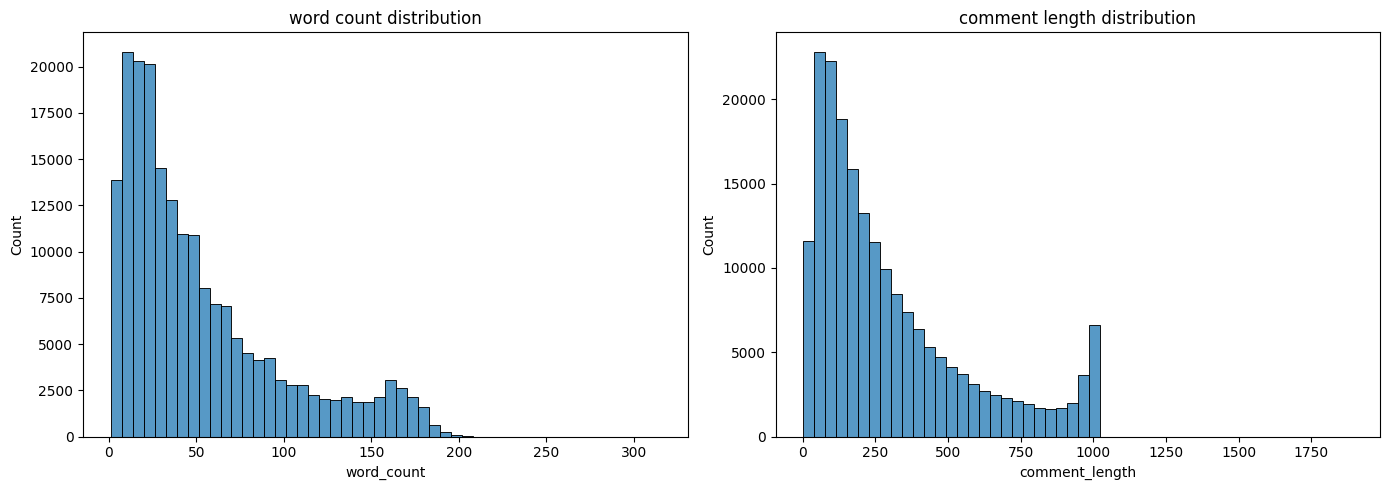

In [35]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.histplot(x='word_count',data=train,bins=50,ax=ax[0])
ax[0].set_title("word count distribution")
ax[0].set_xlabel('word_count')

sns.histplot(x='comment_length',data=train,bins=50,ax=ax[1])
ax[1].set_title("comment length distribution")
ax[1].set_xlabel('comment_length')

plt.tight_layout()
plt.show()


In [36]:
label_list=train['label'].unique()
sorted_label=np.sort(label_list)

sorted_label

array([0, 1, 2, 3])

In [37]:
# Read sample comments from each label
for val in (sorted_label):
    print(f"Sample comment for Label {val}:")
    samples = train[train['label'] == val].sample(5, random_state=42)
    for idx, row in samples.iterrows():
        print(f"\n{row['comment']}")
        print(f"  Upvotes: {row['upvote']}, Downvotes: {row['downvote']}\n")


Sample comment for Label 0:

Well, look at the source. I've gritted my teeth and listened through what she calls her talk radio show a nevvu few times. The discussion mostly amounted to insulting and name-calling, with very little actual content other than her opinions.
  Upvotes: 4, Downvotes: 0


Good luck with wi that.
  Upvotes: 0, Downvotes: 0


You're one to talk about spinning Doc.  Buick USA sales have been increasing, not decreasing over at least the past 6 years, and per the article, it is a niche brand fo GM in the USA.  Countless parts are manufactured in China, even for your beloved Hyundai.  So tell me what vehicles assembled in the USA have Chinese engines and what has made them so "scary"?  Any "scarier" than the early Hyundai Theta engines that rolled off the floor in Alabama?  My local restaurant makes an excellent combo #1, the Chinese are quite capable people.
  Upvotes: 0, Downvotes: 0


everyobdy is a pioneer nowadays.
  Upvotes: 0, Downvotes: 0


So you're argume

In [38]:
# Word frequency analysis  

from collections import Counter
import re
def get_words(com):
    text=str(com).lower() # converts comment into string+ lower case
    text=re.sub(r'[^a-z\s]','',text) # removes anything that is not a-z or a space aka punctuations or symbols 
    return text.split() #converts the modified into list 
    
all_words = []

# Get all words
for comment in train['comment']:
    all_words.extend(get_words(comment)) #extends  add all words into the list
    
word_freq = Counter(all_words) # counter converts the list into a dict with values as freq of the keys
most_freq_words=word_freq.most_common(30)

In [39]:
for word, count in most_freq_words:
    print(f"{word}: {count}")

the: 519017
to: 291158
and: 257212
of: 228626
a: 218975
is: 173967
in: 149897
that: 142720
you: 110754
for: 103472
it: 97238
i: 95443
are: 88074
not: 77791
be: 69068
have: 67086
on: 66650
this: 65889
they: 65178
with: 64946
as: 60481
was: 47695
or: 46171
he: 46014
but: 45413
all: 43587
we: 41349
their: 40687
if: 40615
what: 39994


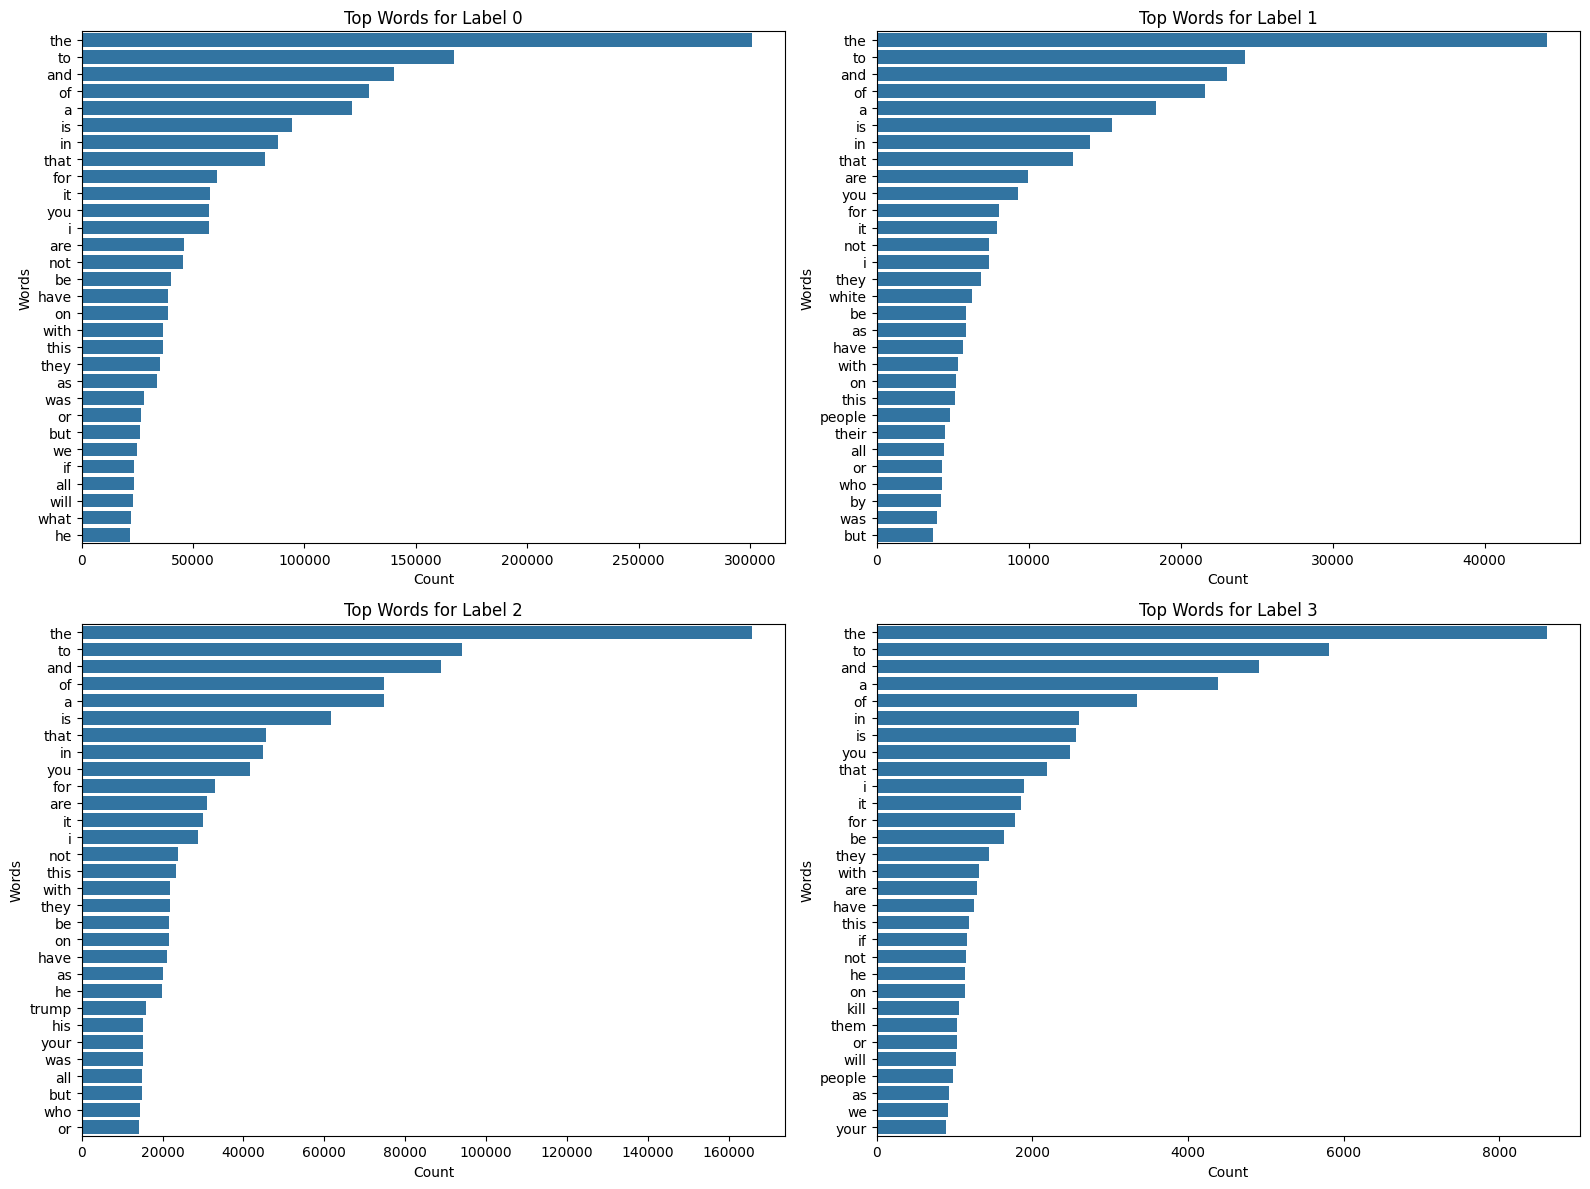

In [40]:
# Word frequency analysis label-wise 

label_top_words = {}

fig, ax = plt.subplots(2, 2, figsize=(16, 12))
ax=ax.ravel()

for idx,l_value in enumerate(sorted_label):
    l_words=[]
    l_comments=train[train['label']==l_value]['comment']
    for com in l_comments:
        l_words.extend(get_words(com))

    word_freq=Counter(l_words)
    
    top_words = word_freq.most_common(30) 
    
    label_top_words[l_value]= set(
        word for word, count in word_freq.most_common(30))
#In Python, a set comprehension only adds the value(s) specified at the very beginning of the expression

    
    
    words, counts = zip(*top_words) #unpacks the dict into 2 diff word and counts tuples

        
    sns.barplot(x=list(counts),y=list(words),ax=ax[idx])
    ax[idx].set_title(f"Top Words for Label {l_value}")
    ax[idx].set_xlabel("Count")
    ax[idx].set_ylabel("Words")

plt.tight_layout()
plt.show()



In [41]:
label_top_words #across all the labels 

{np.int64(0): {'a',
  'all',
  'and',
  'are',
  'as',
  'be',
  'but',
  'for',
  'have',
  'he',
  'i',
  'if',
  'in',
  'is',
  'it',
  'not',
  'of',
  'on',
  'or',
  'that',
  'the',
  'they',
  'this',
  'to',
  'was',
  'we',
  'what',
  'will',
  'with',
  'you'},
 np.int64(1): {'a',
  'all',
  'and',
  'are',
  'as',
  'be',
  'but',
  'by',
  'for',
  'have',
  'i',
  'in',
  'is',
  'it',
  'not',
  'of',
  'on',
  'or',
  'people',
  'that',
  'the',
  'their',
  'they',
  'this',
  'to',
  'was',
  'white',
  'who',
  'with',
  'you'},
 np.int64(2): {'a',
  'all',
  'and',
  'are',
  'as',
  'be',
  'but',
  'for',
  'have',
  'he',
  'his',
  'i',
  'in',
  'is',
  'it',
  'not',
  'of',
  'on',
  'or',
  'that',
  'the',
  'they',
  'this',
  'to',
  'trump',
  'was',
  'who',
  'with',
  'you',
  'your'},
 np.int64(3): {'a',
  'and',
  'are',
  'as',
  'be',
  'for',
  'have',
  'he',
  'i',
  'if',
  'in',
  'is',
  'it',
  'kill',
  'not',
  'of',
  'on',
  'or',
  

**Feature Engineering and time series analyis**

In [42]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197999 entries, 0 to 197999
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   created_date    197999 non-null  object
 1   post_id         197999 non-null  int64 
 2   emoticon_1      197999 non-null  int64 
 3   emoticon_2      197999 non-null  int64 
 4   emoticon_3      197999 non-null  int64 
 5   upvote          197999 non-null  int64 
 6   downvote        197999 non-null  int64 
 7   if_1            197999 non-null  int64 
 8   if_2            197999 non-null  int64 
 9   race            197999 non-null  object
 10  religion        197999 non-null  object
 11  gender          197999 non-null  object
 12  disability      197999 non-null  bool  
 13  comment         197999 non-null  object
 14  label           197999 non-null  int64 
 15  comment_length  197999 non-null  int64 
 16  word_count      197999 non-null  int64 
dtypes: bool(1), int64(11), object(5)
m

In [43]:
train['created_date']

0         2024-01-18 08:43:57.397508+00:00
1         2024-03-24 21:43:11.490017+00:00
2         2024-04-24 20:32:17.014931+00:00
3         2023-05-28 22:00:14.214527+00:00
4         2023-09-09 23:12:05.689498+00:00
                        ...               
197995    2023-02-04 10:39:30.581185+00:00
197996    2023-11-01 17:16:51.337370+00:00
197997    2024-03-09 15:46:22.542539+00:00
197998    2023-08-07 17:23:40.163756+00:00
197999    2023-08-26 19:36:00.380158+00:00
Name: created_date, Length: 197999, dtype: object

In [44]:
def extract_date_features(df):
    df['created_date']=pd.to_datetime(df['created_date'],format='%Y-%m-%d %H:%M:%S.%f%z')
    df['month']=df['created_date'].dt.month
    df['year']=df['created_date'].dt.year
    df['day']=df['created_date'].dt.day
    df['day_of_the_week']=df['created_date'].dt.dayofweek #0-mon, 6-sun
    df['hour']=df['created_date'].dt.hour
    df['is_weekend']=df['day_of_the_week'].isin([5,6]).astype(int)
    df['is_night'] = df['hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)

    return df

train=extract_date_features(train)

In [45]:
#comments over time
print("comments over years"+'\n',train['year'].value_counts().sort_index(),'\n')

print("coments over the months"+'\n',train['month'].value_counts().sort_index())

comments over years
 year
2022      7517
2023    100405
2024     90077
Name: count, dtype: int64 

coments over the months
 month
1     18983
2     19526
3     21280
4     20142
5     23573
6     13426
7     11822
8     14223
9     12373
10    13925
11    13417
12    15309
Name: count, dtype: int64


In [46]:
print(train.shape)
print(len(train['created_date'].unique()))

(197999, 24)
197995


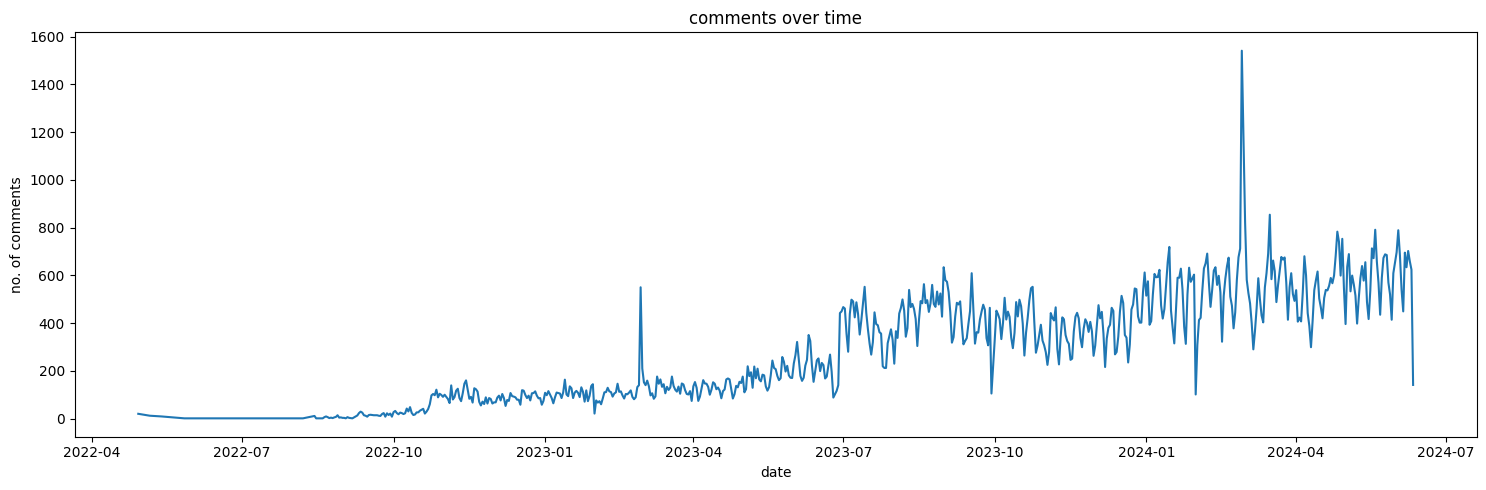

In [47]:
# Comments over time
plt.figure(figsize=(15,5))
train.groupby(train['created_date'].dt.date).size().plot()
#groupby-> tracks change over time , value_counts ranks by frequency
plt.title("comments over time")
plt.xlabel("date")
plt.ylabel("no. of comments")
plt.tight_layout()
plt.show()

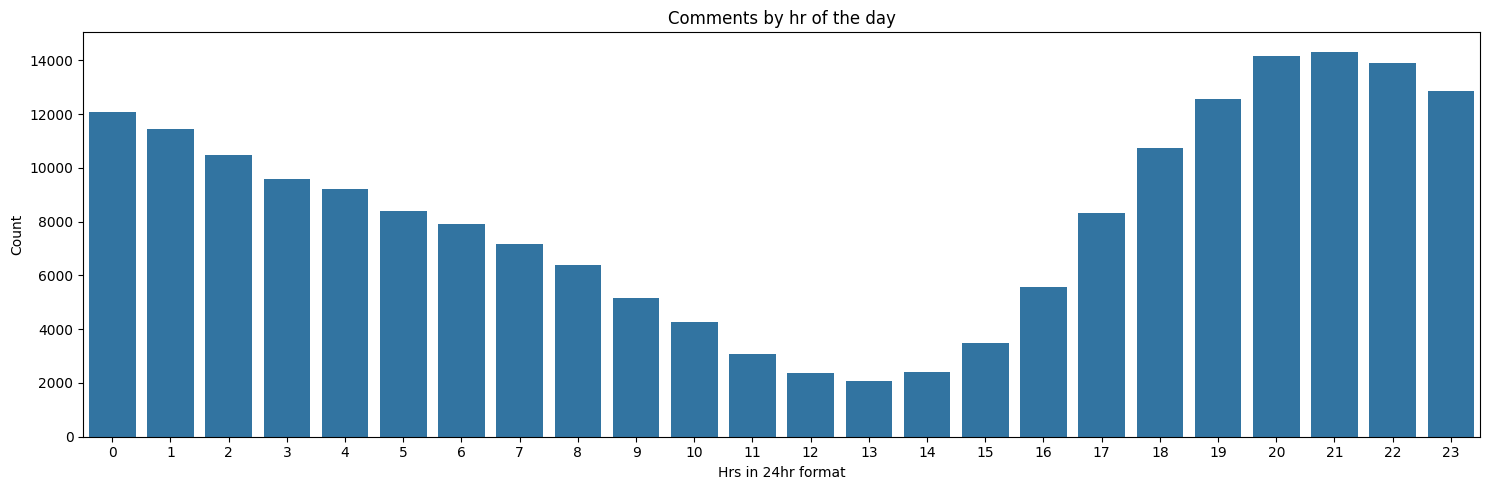

In [48]:
# Comments by hour of day
plt.figure(figsize=(15,5))
sns.countplot(x='hour', data=train)
plt.title("Comments by hr of the day")
plt.xlabel("Hrs in 24hr format")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [49]:
train['day_of_the_week'].unique()

array([3, 6, 2, 5, 0, 1, 4], dtype=int32)

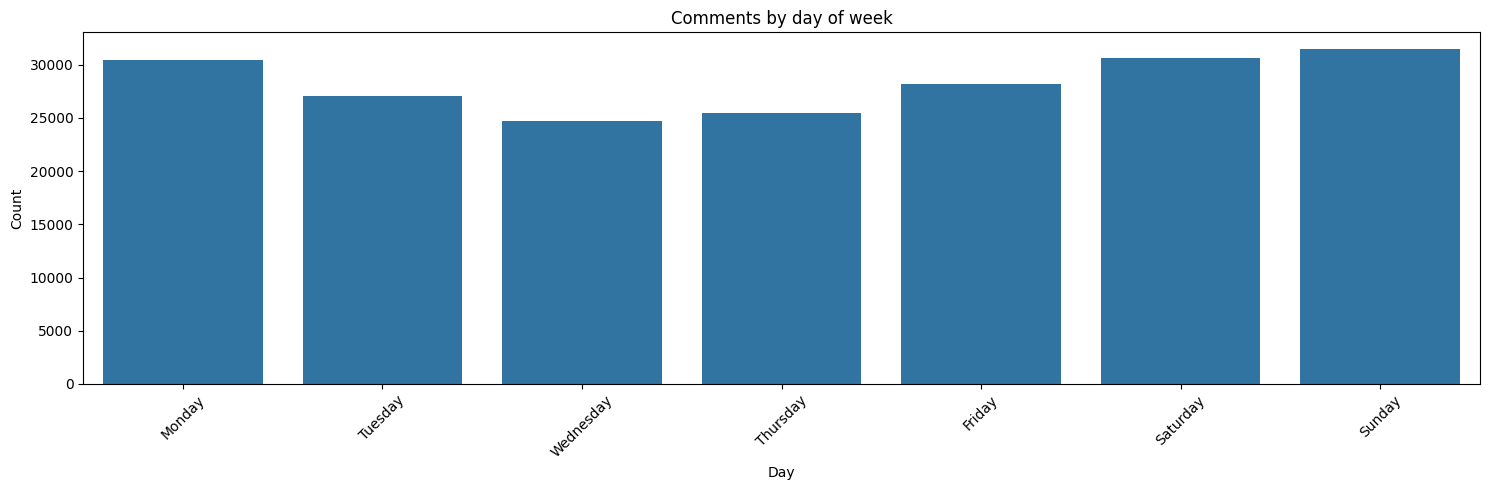

In [50]:
# Comments by day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(15,5))
sns.countplot(x='day_of_the_week', data=train)
plt.title("Comments by day of week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(range(7), day_names, rotation=45)
plt.tight_layout()
plt.show()

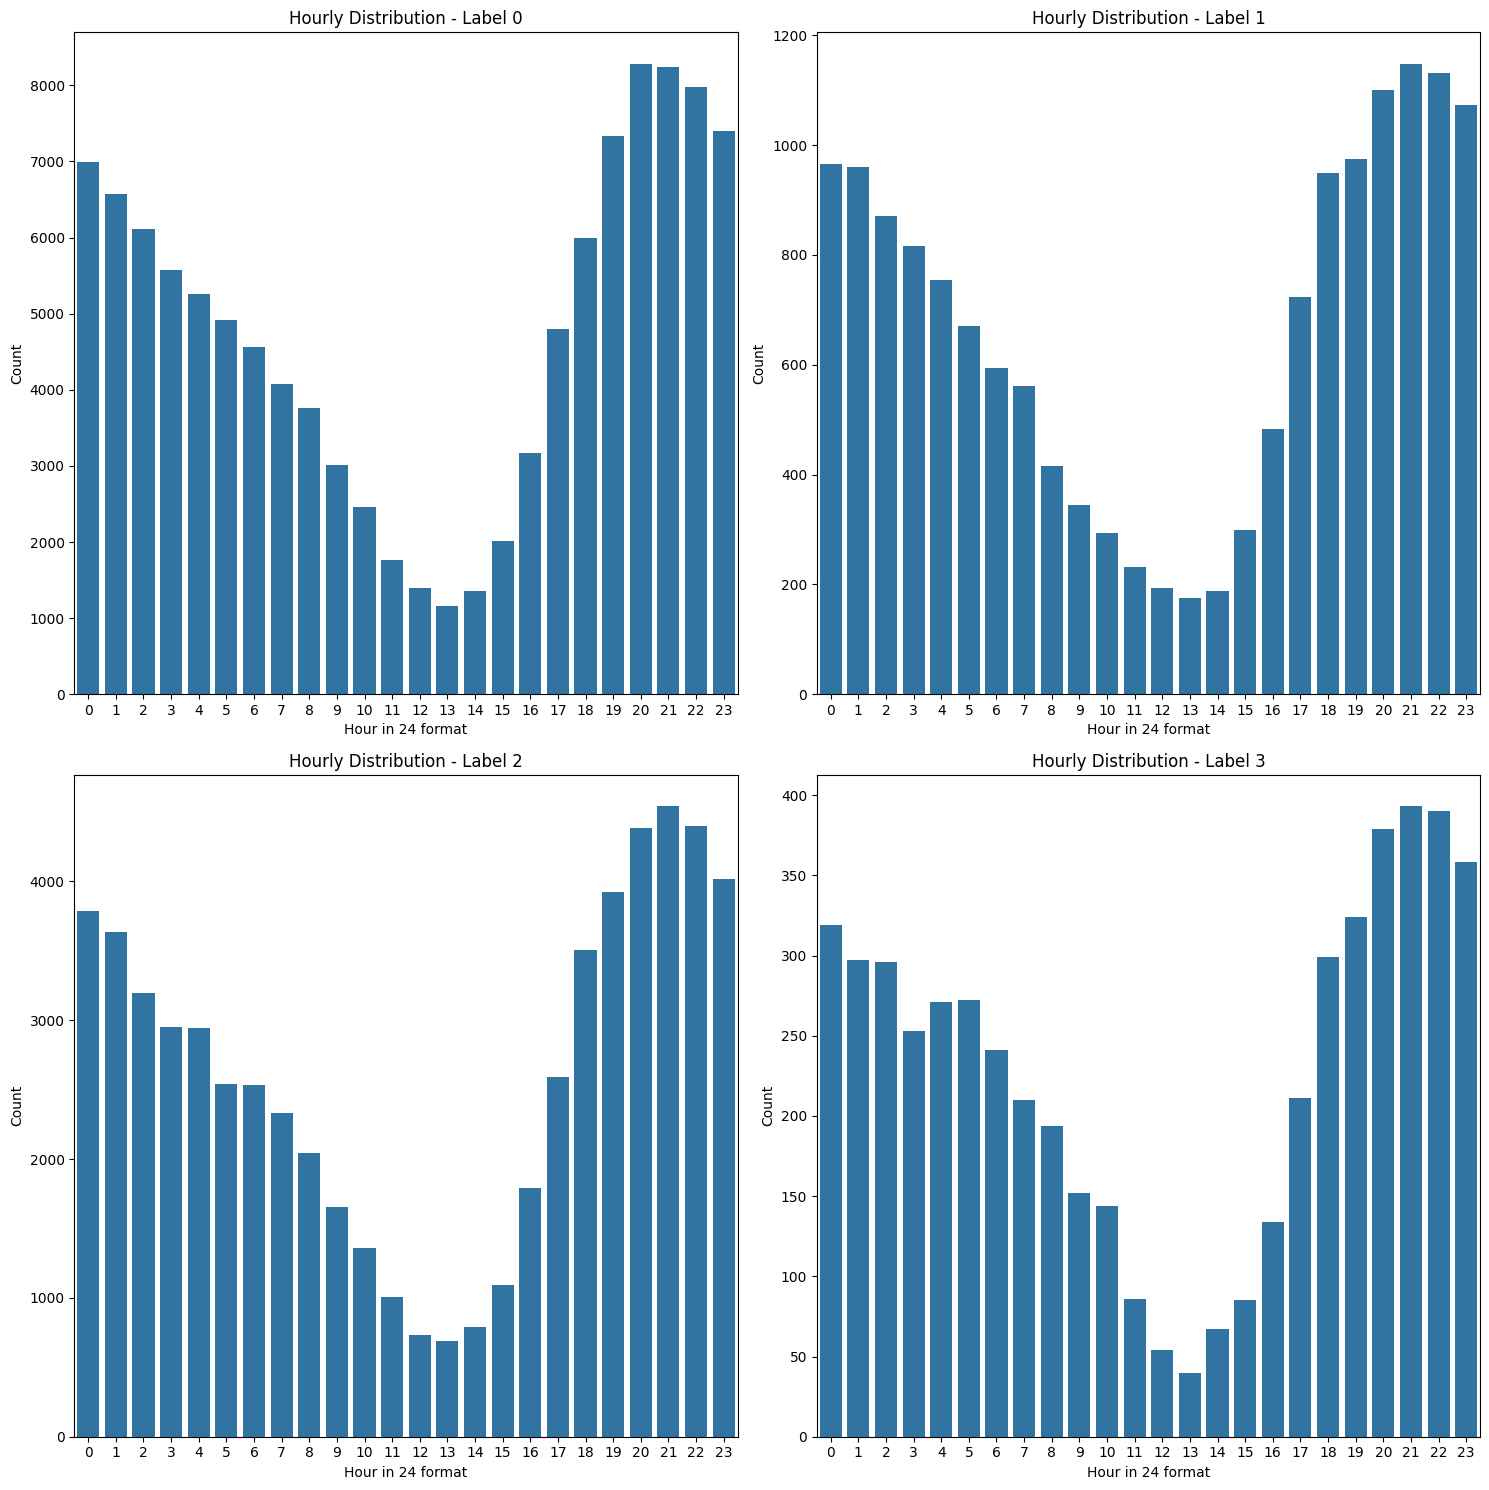

In [51]:
#p(hr|label)
fig,ax=plt.subplots(2,2,figsize=(15,15))
ax=ax.ravel()

for i,l in enumerate(sorted_label):
    label_data=train[train['label']==l]
    sns.countplot(x='hour',data=label_data,ax=ax[i])
    ax[i].set_title(f'Hourly Distribution - Label {l}')
    ax[i].set_xlabel("Hour in 24 format")
    ax[i].set_ylabel("Count")
    
plt.tight_layout()
plt.show()

In [52]:
#no. of comments in / post
comments_per_post=train['post_id'].value_counts() #comments per post
comments_per_post.describe()

count       52.000000
mean      3807.673077
std      11799.820229
min          1.000000
25%         10.000000
50%         27.500000
75%        243.750000
max      69529.000000
Name: count, dtype: float64

In [53]:
comments_per_post

post_id
72     69529
39     40946
120    24324
31     17022
73     14882
71     13308
40      5488
123     4809
118     2692
61      1149
24      1080
84       915
111      351
70       208
105      165
91       156
64       141
102      121
85       104
103       73
77        57
115       50
87        44
100       40
93        37
83        30
76        25
75        25
89        23
90        22
104       21
101       18
109       16
79        13
96        13
50        13
129       12
42        11
74        10
82        10
43        10
86         7
95         6
66         6
88         4
67         4
108        2
125        2
110        2
20         1
113        1
65         1
Name: count, dtype: int64

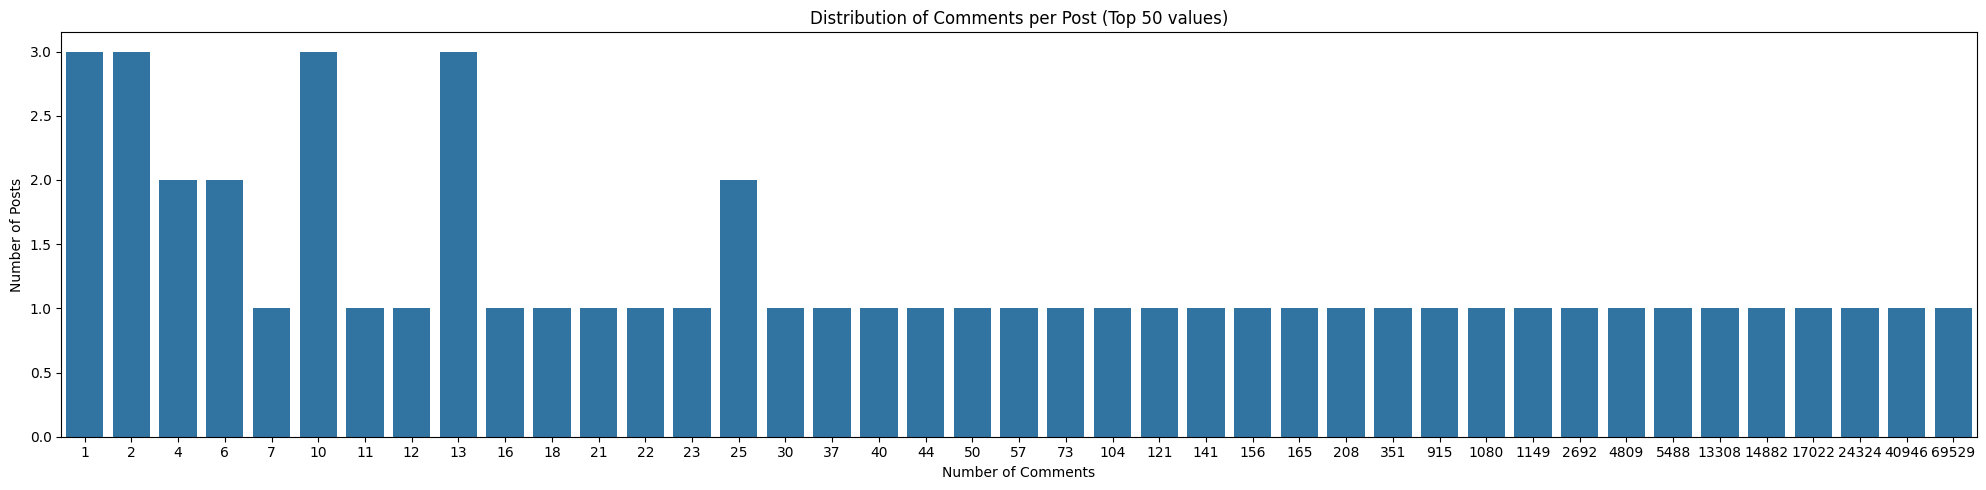

In [54]:
comments_per_post_2=comments_per_post.value_counts().sort_index().head(50) # x post with x comments  
plt.figure(figsize=(20,5))
sns.barplot(x=comments_per_post_2.index , y=comments_per_post_2.values)
plt.title("Distribution of Comments per Post (Top 50 values)")
plt.xlabel('Number of Comments')
plt.ylabel('Number of Posts')

plt.tight_layout()
plt.show()

In [55]:
busy_posts = comments_per_post.head(5).index
busy_posts

Index([72, 39, 120, 31, 73], dtype='int64', name='post_id')

In [56]:
for p in busy_posts:
    p_data=train[train['post_id']==p]
    print(f"\nlabel distribution for post_id {p}")
    display(p_data['label'].value_counts())
    


label distribution for post_id 72


label
0    40136
2    21618
1     6382
3     1393
Name: count, dtype: int64


label distribution for post_id 39


label
0    23475
2    13701
1     2271
3     1499
Name: count, dtype: int64


label distribution for post_id 120


label
0    13389
2     8156
1     1927
3      852
Name: count, dtype: int64


label distribution for post_id 31


label
0    9899
2    5200
1    1441
3     482
Name: count, dtype: int64


label distribution for post_id 73


label
0    8401
2    4962
1     893
3     626
Name: count, dtype: int64

In [57]:
for post in busy_posts:
    post_data = train[train['post_id'] == post]
    print(f"\nPost {post} - Label distribution:")
    print(post_data['label'].value_counts())



Post 72 - Label distribution:
label
0    40136
2    21618
1     6382
3     1393
Name: count, dtype: int64

Post 39 - Label distribution:
label
0    23475
2    13701
1     2271
3     1499
Name: count, dtype: int64

Post 120 - Label distribution:
label
0    13389
2     8156
1     1927
3      852
Name: count, dtype: int64

Post 31 - Label distribution:
label
0    9899
2    5200
1    1441
3     482
Name: count, dtype: int64

Post 73 - Label distribution:
label
0    8401
2    4962
1     893
3     626
Name: count, dtype: int64


In [58]:
def avg_word_length(text):
    words = str(text).split()
    return sum(len(w) for w in words) / len(words) if words else 0



In [59]:
def create_engagement_features(df):
    df['total_votes']=df['upvote']+df['downvote']
    df['engagement_ratio']=df['upvote']/(df['total_votes']+1)
    # +1 assumes natural engagement   incase up nd doenvotes=0 
    df['vote_diff']= df['upvote'] - df['downvote']
    df['avg_word_length']=df['comment'].apply(avg_word_length)

    
    df['capital_ratio'] = df['comment'].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))

    df['total_emoticons']=df['emoticon_1']+df['emoticon_2']+df['emoticon_3']    
    df['exclamation_count'] = df['comment'].apply(lambda x: str(x).count('!'))
    df['question_count'] = df['comment'].apply(lambda x: str(x).count('?'))
    df['controversy_score']=(df['upvote'] * df['downvote']) / (df['total_votes'] + 1)
    df['mention_count'] = df['comment'].apply(lambda x: str(x).count('@'))
    df['url_count'] = df['comment'].apply(lambda x: str(x).count('http'))
    return df
    

train=create_engagement_features(train)

In [60]:
#checking correlation of new features 
new_feature=['total_votes','engagement_ratio','vote_diff','total_emoticons','avg_word_length','capital_ratio','exclamation_count','question_count']
for f in new_feature:
    corr = train[[f,'label']].corr().iloc[0, 1] #takes correlation with f and label only 
    print(f"{f}: {corr:.4f}")

#Measures linear relationship with label

total_votes: 0.0490
engagement_ratio: 0.0176
vote_diff: 0.0231
total_emoticons: 0.0123
avg_word_length: -0.0266
capital_ratio: -0.0195
exclamation_count: 0.0352
question_count: 0.0066


In [61]:
from scipy import stats
cat_f=['race', 'religion', 'gender', 'disability','is_weekend','emoticon_1','emoticon_2','emoticon_3','total_emoticons']

# Chi-square test for categorical features
for f in cat_f:
    cont_table=pd.crosstab(train[f],train['label'])
    chi2, p_value, dof, expected = stats.chi2_contingency(cont_table)
    print(f"\n{f}:")
    print(f"  Chi-square: {chi2:.4f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}")


#note coorealtion num vs num 
#anova : num vs cat (how label differs across diff cat)
#chi sq: cat vs cat 

# p < 0.05 means variables are dependent on each other i.e significant 


race:
  Chi-square: 53290.6601
  P-value: 0.000000
  Significant: Yes

religion:
  Chi-square: 42929.9973
  P-value: 0.000000
  Significant: Yes

gender:
  Chi-square: 29493.1239
  P-value: 0.000000
  Significant: Yes

disability:
  Chi-square: 857.5486
  P-value: 0.000000
  Significant: Yes

is_weekend:
  Chi-square: 4.1761
  P-value: 0.243062
  Significant: No

emoticon_1:
  Chi-square: 160.4675
  P-value: 0.000403
  Significant: Yes

emoticon_2:
  Chi-square: 196.6914
  P-value: 0.000000
  Significant: Yes

emoticon_3:
  Chi-square: 305.3695
  P-value: 0.000000
  Significant: Yes

total_emoticons:
  Chi-square: 286.4823
  P-value: 0.000000
  Significant: Yes


In [62]:
# ANOVA for numerical features
#Measures difference in distribution across classes

num_f = ['upvote', 'downvote', 'comment_length', 'word_count']

print("\nANOVA test results (feature vs label):")
for f in num_f:
    groups = [train[train['label'] == label][f].values 
              for label in sorted(train['label'].unique())]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\n{f}:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}") #There is a statistically significant difference between groups
    



ANOVA test results (feature vs label):

upvote:
  F-statistic: 203.1062
  P-value: 0.000000
  Significant: Yes

downvote:
  F-statistic: 214.9125
  P-value: 0.000000
  Significant: Yes

comment_length:
  F-statistic: 471.0441
  P-value: 0.000000
  Significant: Yes

word_count:
  F-statistic: 414.7388
  P-value: 0.000000
  Significant: Yes


**Data Preprocessing & train-validation split**


In [63]:
train

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,engagement_ratio,vote_diff,avg_word_length,capital_ratio,total_emoticons,exclamation_count,question_count,controversy_score,mention_count,url_count
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,unknown,...,0.000000,-1,4.950000,0.016807,0,0,0,0.000000,0,0
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,unknown,...,0.857143,6,4.854545,0.013953,0,0,0,0.000000,0,0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,unknown,...,0.000000,0,4.654135,0.017287,2,0,0,0.000000,0,0
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,unknown,...,0.833333,5,5.133333,0.043478,0,0,0,0.000000,0,0
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,unknown,...,0.000000,0,5.375000,0.011765,0,0,0,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,unknown,...,0.666667,2,4.761905,0.016529,0,0,1,0.000000,0,0
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,unknown,...,0.500000,1,5.833333,0.008130,0,0,0,0.000000,0,0
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,unknown,...,0.000000,0,4.347826,0.016260,0,0,0,0.000000,0,0
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,...,0.384615,-2,5.454545,0.000000,2,0,1,2.692308,0,0


**MILESTONE 2**

In [64]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197999 entries, 0 to 197999
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   created_date       197999 non-null  datetime64[ns, UTC]
 1   post_id            197999 non-null  int64              
 2   emoticon_1         197999 non-null  int64              
 3   emoticon_2         197999 non-null  int64              
 4   emoticon_3         197999 non-null  int64              
 5   upvote             197999 non-null  int64              
 6   downvote           197999 non-null  int64              
 7   if_1               197999 non-null  int64              
 8   if_2               197999 non-null  int64              
 9   race               197999 non-null  object             
 10  religion           197999 non-null  object             
 11  gender             197999 non-null  object             
 12  disability         197999 non-null 

In [65]:
#Identify the month that occurs the most number of times in the dataset and enter the answer as a lowercase string
comments_per_month=train['month'].value_counts()
print('the month that occurs the most number of times',comments_per_month.idxmax())

#Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset?
emotico_maximum=train['total_emoticons'].max()
print('max value in total_emoticons',emotico_maximum)

#median of comment length of label 3
label_3=train.loc[train['label']==3]
print('median of comment length of label 3 :',label_3['comment_length'].median())

#What is the average word count (number of words separated by whitespace) for comments that are assigned a label of 1? 
label_1=label_3=train.loc[train['label']==1]
print('avg word_Count assigned to label 1 : ',label_1['word_count'].mean())

#How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive.
trump_comment = train[train['comment'].str.contains('trump', case=False, na=False)]
print("comments in the entire dataset contain the substring trump",trump_comment.shape)

the month that occurs the most number of times 5
max value in total_emoticons 60
median of comment length of label 3 : 128.0
avg word_Count assigned to label 1 :  57.23344641286594
comments in the entire dataset contain the substring trump (24398, 35)


In [66]:
stopwords=['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he',
            'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your'] #given in milestones

def clean_text(com_list):
    #words=text.split()
    words=[w for w in com_list if w not in stopwords]
    return words

train['comment']= train['comment'].apply(get_words)
train['clean_comment']=train['comment'].apply(clean_text)
#test_p['clean_comment']=test_p['comment'].apply(clean_text)


In [67]:
train['clean_word_count']=train['clean_comment'].apply(lambda x: len(str(x).split())) 
print('words are left in the text of first comment  after removing punv and stop words',train['clean_word_count'][0])

words are left in the text of first comment  after removing punv and stop words 12


In [68]:
all_tokens = [w for tokens in train['clean_comment'] for w in tokens]
len(set(all_tokens))

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer(
    stop_words='english', # Reduces noise by removing common words like:the, is, and, etc.
    min_df=5, #Keeps only terms that appear in at least 5 documents
    ngram_range=(1,2) #includes unigrams and bigrams 
)


train['text_for_tfidf'] = train['clean_comment'].apply(lambda x: ' '.join(x))

X = vectorizer.fit_transform(train['text_for_tfidf'])
print(len(vectorizer.get_feature_names_out()))

127183


In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train['upvote_scaled'] = scaler.fit_transform(train[['upvote']])

# value corresponding to upvote = 10
scaled_10 = (10 - train['upvote'].min()) / (train['upvote'].max() - train['upvote'].min())
print(scaled_10)

0.04975124378109453


In [70]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


**MILESTONE 3**

In [71]:
'''
train_p=train_c.copy()
test_p=test_c.copy()

#Split the train dataset using train_test_split with random_state=42 such that 80% is training data and remaining 20% is validation data. store the data as X_train, X_val, y_train, y_val. Lets say training data (X_train) has shape (a,b) where a is number of rows and b is the number of features, similarly validation set (X_val) has shape (c,d) where c is the number of rows and d is the number of features. what will be the value of a + c ? 
y=train_p['label']
x=train_p.drop('label',axis=1)

x_train,x_val,y_train,y_val=train_test_split(x,y,random_state=42,test_size=0.2)

x_train=extract_date_features(x_train)
x_val=extract_date_features(x_val)
test_p=extract_date_features(test_p)
print(X.shape[0])

num_col=x_train.select_dtypes(include=['int64','int32']).columns.to_list()
bool_col=x_train.select_dtypes(include=['bool']).columns.to_list()
cat_col=x_train.select_dtypes(include=['object']).columns.to_list()
text_col=['comment']

#handling null values
for col in cat_col:
    x_train[col]=x_train[col].fillna('none')
    x_val[col]=x_val[col].fillna('none')
    test_p[col]=test_p[col].fillna('none')
    
cat_pipeline=Pipeline([("ohe",OneHotEncoder(handle_unknown="ignore"))])
preprocessor=ColumnTransformer([('cat',cat_pipeline,cat_col)])

x_train_p=preprocessor.fit_transform(x_train)
x_val_p=preprocessor.transform(x_val)
test_pre=preprocessor.transform(test_p)

b = x_train.shape[1]
print("no. of features after imputation,ohe,and vectorizer",b)

vectorizer=CountVectorizer()
x_train_vec = vectorizer.fit_transform(x_train['comment'])
x_val_vec = vectorizer.transform(x_val['comment'])
row_sum = x_train_vec[1].sum()

print("sum of counts at index 1",row_sum)

# Convert to int (True → 1, False → 0)
x_train['disability'] = x_train['disability'].astype(int)
x_val['disability'] = x_val['disability'].astype(int)
test_p['disability']=test_p['disability'].astype(int)
# Compute total sum
total_sum = x_train['disability'].sum() + x_val['disability'].sum()

print('total_sum of disable from both train and val sets ',total_sum)



X_train_num = x_train.select_dtypes(include=['int64','int32', 'float64'])
X_val_num = x_val.select_dtypes(include=['int64','int32' ,'float64'])
test_num=test_p.select_dtypes(include=['int64','int32', 'float64'])

# Step 3: scale
scaler = StandardScaler()
x_train_p= scaler.fit_transform(X_train_num)
x_val_p = scaler.transform(X_val_num)
test_pre=scaler.transform(test_num)

# Step 4: number of features seen during fit
print(scaler.n_features_in_)'''

'\ntrain_p=train_c.copy()\ntest_p=test_c.copy()\n\n#Split the train dataset using train_test_split with random_state=42 such that 80% is training data and remaining 20% is validation data. store the data as X_train, X_val, y_train, y_val. Lets say training data (X_train) has shape (a,b) where a is number of rows and b is the number of features, similarly validation set (X_val) has shape (c,d) where c is the number of rows and d is the number of features. what will be the value of a + c ? \ny=train_p[\'label\']\nx=train_p.drop(\'label\',axis=1)\n\nx_train,x_val,y_train,y_val=train_test_split(x,y,random_state=42,test_size=0.2)\n\nx_train=extract_date_features(x_train)\nx_val=extract_date_features(x_val)\ntest_p=extract_date_features(test_p)\nprint(X.shape[0])\n\nnum_col=x_train.select_dtypes(include=[\'int64\',\'int32\']).columns.to_list()\nbool_col=x_train.select_dtypes(include=[\'bool\']).columns.to_list()\ncat_col=x_train.select_dtypes(include=[\'object\']).columns.to_list()\ntext_col

**PREPROCESSING**

In [72]:

train_c=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_c=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

In [73]:
label_counts=train_c['label'].value_counts(normalize=True)*100
label_counts

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64

In [74]:
train_p=train_c.copy()
test_p=test_c.copy()
print("shape of train set :", train_p.shape )
print("shape of test set: ",test_p.shape)


shape of train set : (198000, 15)
shape of test set:  (102000, 14)


In [75]:
train_p['post_id'].nunique()

52

In [76]:
train_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [77]:
train_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [78]:
post_stats = train_p.groupby('post_id')['label'].agg(
    post_label_mean='mean',
    post_label_std='std', 
    post_comment_count='count'
).reset_index()

train_p = train_p.merge(post_stats, on='post_id', how='left')
test_p  = test_p.merge(post_stats, on='post_id', how='left')

In [79]:
print(test_p[['post_label_mean','post_label_std','post_comment_count']].isna().sum())


post_label_mean       0
post_label_std        0
post_comment_count    0
dtype: int64


In [80]:
def engineer(df):
    df = df.copy()
    txt=df['comment']
    df['total_votes']=df['upvote']+df['downvote']
    df['engagement_ratio']=df['upvote']/(df['total_votes']+1)
    # +1 assumes natural engagement   incase up nd doenvotes=0 
    df['vote_diff']= df['upvote'] - df['downvote']
    df['comment_length']=txt.str.len()
    df['word_count']=txt.str.split().str.len().fillna(0).astype(int)
    df['avg_word_length']=(df['comment_length']/(df['word_count']+1)).round(2)
    df['uppercase_ratio']=txt.str.count(r'[A-Z]')/(df['comment_length']+1)
    df['digit_ratio']=txt.str.count(r'\d')/(df['comment_length']+1)
    df['special_ratio']=txt.str.count(r'[^a-zA-Z0-9\s]')/(df['comment_length']+1)
    df['exclamation']=txt.str.count('!')
    df['question']=txt.str.count(r'\?')
    df['url_count']=txt.str.count('http')
    df['is_short']=(df['comment_length']<100).astype(int)
    df['is_very_short']=(df['comment_length']<50).astype(int)
    df['total_emoticons']=df['emoticon_1']+df['emoticon_2']+df['emoticon_3']    
    df['has_emoticon']=(df['total_emoticons']>0).astype(int)
    # Interaction of if_1 with identity flags
    df['if1_race'] = df['if_1'] * (df['race'] != 'unknown').astype(int)
    df['if2_religion'] = df['if_2'] * (df['religion'] != 'unknown').astype(int)
    df['if2_is_4']=(df['if_2']==4).astype(int)
    df['if2_is_10']=(df['if_2']==10).astype(int)
    df['if2_other']=((df['if_2']!=4)&(df['if_2']!=10)).astype(int)
    df['if1_active']=df['if_1'].isin([4,5,6,10]).astype(int)
    df['if1_is_zero']=(df['if_1']==0).astype(int)
    df['if1_if2_interact']=df['if_1']*df['if_2']
    df['has_identity']=(~((df['race']=='unknown') & (df['religion']=='unknown') & (df['gender']=='unknown'))).astype(int)
    df['identity_missing']=1-df['has_identity']
    df['l3_bucket']=((df['if_2']==10)&(df['if_1']==0)&(df['race']=='unknown') &(df['comment_length']<200)).astype(int)
    
    return df 
    
                                                        

In [81]:
'''# After engineer(), verify l3_bucket is working
print("l3_bucket value counts:", x['l3_bucket'].value_counts())
print("if1_race non-zero count:", (x['if1_race'] != 0).sum())
print("has_identity counts:", x['has_identity'].value_counts())'''

'# After engineer(), verify l3_bucket is working\nprint("l3_bucket value counts:", x[\'l3_bucket\'].value_counts())\nprint("if1_race non-zero count:", (x[\'if1_race\'] != 0).sum())\nprint("has_identity counts:", x[\'has_identity\'].value_counts())'

In [82]:
#separating target 
target='label'
y=train_p['label']
x=train_p.drop(target,axis=1)


#feature engineering

#1)date-time
x=extract_date_features(x)
test_p=extract_date_features(test_p)

#2) comments
x['clean_comment']=x['comment'].str.lower().str.replace(r'[^a-z\s]',' ',regex=True) 
test_p['clean_comment']=test_p['comment'].str.lower().str.replace(r'[^a-z\s]',' ',regex=True) 

x['disability'] = x['disability'].astype(int)
test_p['disability']=test_p['disability'].astype(int)
#handling null values
x.fillna('unknown',inplace=True)
test_p.fillna('unknown',inplace=True)

x=engineer(x)
test_p=engineer(test_p)



bool_col=x.select_dtypes(include=['boolean']).columns.to_list()
#converting boolean col into it type  T=1, F=0





/tmp/ipykernel_17/2686666582.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  x.fillna('unknown',inplace=True)


In [83]:
test_p.shape

(102000, 52)

In [84]:
#splitting train set into train and val set
x_train,x_val,y_train,y_val=train_test_split(x,y,random_state=42,test_size=0.2)



In [85]:

'''from sklearn.impute import SimpleImputer

cols = ['post_label_mean','post_label_std','post_comment_count']

imputer = SimpleImputer(strategy='median')
x_train[cols] = imputer.fit_transform(x_train[cols])  # was train_p — wrong
x_val[cols]   = imputer.transform(x_val[cols])
test_p[cols]  = imputer.transform(test_p[cols])'''


"from sklearn.impute import SimpleImputer\n\ncols = ['post_label_mean','post_label_std','post_comment_count']\n\nimputer = SimpleImputer(strategy='median')\nx_train[cols] = imputer.fit_transform(x_train[cols])  # was train_p — wrong\nx_val[cols]   = imputer.transform(x_val[cols])\ntest_p[cols]  = imputer.transform(test_p[cols])"

In [86]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158400 entries, 40336 to 121958
Data columns (total 52 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   created_date        158400 non-null  datetime64[ns, UTC]
 1   post_id             158400 non-null  int64              
 2   emoticon_1          158400 non-null  int64              
 3   emoticon_2          158400 non-null  int64              
 4   emoticon_3          158400 non-null  int64              
 5   upvote              158400 non-null  int64              
 6   downvote            158400 non-null  int64              
 7   if_1                158400 non-null  int64              
 8   if_2                158400 non-null  int64              
 9   race                158400 non-null  object             
 10  religion            158400 non-null  object             
 11  gender              158400 non-null  object             
 12  disability       

In [87]:
num_col=x_train.select_dtypes(include=['int64','int32','float64']).columns.to_list()
#num_col = [c for c in num_col if c not in ['post_label_mean', 'post_label_std', 'post_comment_count']]
txt_col='clean_comment'
cat_col=['race','religion','gender']

In [88]:
num_col

['post_id',
 'emoticon_1',
 'emoticon_2',
 'emoticon_3',
 'upvote',
 'downvote',
 'if_1',
 'if_2',
 'disability',
 'post_label_mean',
 'post_comment_count',
 'month',
 'year',
 'day',
 'day_of_the_week',
 'hour',
 'is_weekend',
 'is_night',
 'total_votes',
 'engagement_ratio',
 'vote_diff',
 'comment_length',
 'word_count',
 'avg_word_length',
 'uppercase_ratio',
 'digit_ratio',
 'special_ratio',
 'exclamation',
 'question',
 'url_count',
 'is_short',
 'is_very_short',
 'total_emoticons',
 'has_emoticon',
 'if1_race',
 'if2_religion',
 'if2_is_4',
 'if2_is_10',
 'if2_other',
 'if1_active',
 'if1_is_zero',
 'if1_if2_interact',
 'has_identity',
 'identity_missing',
 'l3_bucket']

In [89]:
cat_pipeline=Pipeline([("ohe",OneHotEncoder(handle_unknown="ignore"))])#returns sparse mtrix 

num_pipeline=Pipeline([('scaler',StandardScaler())])#returns dense mtrix 


preprocessor=ColumnTransformer([('cat',cat_pipeline,cat_col),
                               ('num',num_pipeline,num_col)])
x_train_num = preprocessor.fit_transform(x_train)
x_val_num   = preprocessor.transform(x_val)
test_num  = preprocessor.transform(test_p)

#sparse 

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Word TF-IDF
tfidf_w = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    min_df=5,
    max_df=0.9,strip_accents='unicode',
    sublinear_tf=True,
    lowercase=True
)

# Character TF-IDF
tfidf_c = TfidfVectorizer(
    max_features=4000,
    analyzer='char_wb',
    ngram_range=(3,5),
    min_df=5,
    max_df=0.9,strip_accents='unicode',
    sublinear_tf=True,
    lowercase=True
)

# Fit on train
x_train_w = tfidf_w.fit_transform(x_train[txt_col])
x_train_c = tfidf_c.fit_transform(x_train[txt_col])

# Transform val
x_val_w = tfidf_w.transform(x_val[txt_col])
x_val_c = tfidf_c.transform(x_val[txt_col])

# Transform test
test_w = tfidf_w.transform(test_p[txt_col])
test_c = tfidf_c.transform(test_p[txt_col])

# returns sparse matrix 

In [91]:
# Combine
x_train_text = hstack([x_train_w, x_train_c])
x_val_text   = hstack([x_val_w, x_val_c])
test_text  = hstack([test_w, test_c])

from scipy.sparse import csr_matrix, hstack
'''
# convert numeric → sparse
x_train_num = csr_matrix(x_train_num)
x_val_num   = csr_matrix(x_val_num)
test_num  = csr_matrix(test_num)'''

# combine with text
x_train_final = hstack([x_train_num, x_train_text])
x_val_final   = hstack([x_val_num, x_val_text])
test_final  = hstack([test_num, test_text])



In [92]:
print("test_p shape:", test_p.shape)
print("test_num shape:", test_num.shape)
print("test_text shape:", test_text.shape)

test_p shape: (102000, 52)
test_num shape: (102000, 67)
test_text shape: (102000, 24000)


In [93]:
test_final.shape

(102000, 24067)

In [94]:
results={}

In [95]:
def evaluate(m_name,model,x_train_final,x_val_final,y_train,y_val):
    model.fit(x_train_final,y_train)
    pred=model.predict(x_val_final)
    acc=accuracy_score(y_val,pred)
    f1m=f1_score(y_val,pred,average='macro')
    f1w = f1_score(y_val, pred, average='weighted')
    f1p = f1_score(y_val, pred, average=None)
    print(f"Val Accuracy  : {acc:.4f}")
    print(f" Macro F1    : {f1m:.4f}")
    #print(f"Label 3 preds : {(pred==3).sum()}")
    print(f"Per-class F1 : {f1p}")
    print("classification_report\n",classification_report(y_val, pred)) #gives recall,precision
    cm=confusion_matrix(y_val, pred) #true lables vs predicted labels 
    plt.figure(figsize=(5,5))
    sns.heatmap(cm,cmap='coolwarm',annot=True,center=0)
    plt.title('Confusion Matrix - Baseline Logistic Regression')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    results[m_name] = {
    'accuracy': acc,
    'f1_macro': f1m,
    'f1_weighted': f1w,
    'model': model}
    return pred 

**Model Training with log regression(fast,saga,comaparasion)**

In [96]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(enumerate(weights))
print(weight_dict)
# Expected something like: {0: 0.43, 1: 3.1, 2: 0.79, 3: 9.0}

{0: np.float64(0.4321304248191272), 1: np.float64(3.118355776045358), 2: np.float64(0.7967486217858436), 3: np.float64(9.082568807339449)}


Val Accuracy  : 0.7873
 Macro F1    : 0.6205
Per-class F1 : [0.95112673 0.65162779 0.64050174 0.23856859]
classification_report
               precision    recall  f1-score   support

           0       0.95      0.95      0.95     22534
           1       0.55      0.79      0.65      3219
           2       0.85      0.51      0.64     12738
           3       0.15      0.65      0.24      1109

    accuracy                           0.79     39600
   macro avg       0.63      0.73      0.62     39600
weighted avg       0.87      0.79      0.81     39600



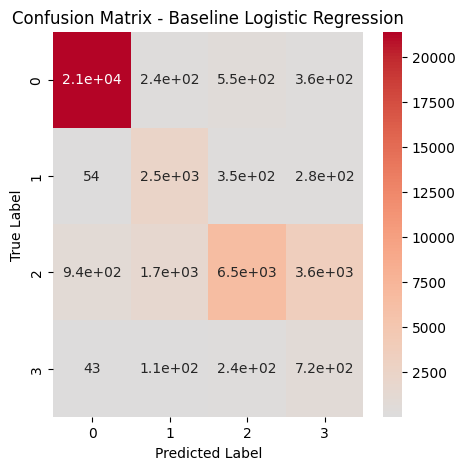

array([0, 2, 2, ..., 0, 2, 3])

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)

evaluate('Logistic Regression',
    LogisticRegression(C=1.0, solver='saga', max_iter=200, tol=1e-2,
                       class_weight='balanced', n_jobs=-1, random_state=42),x_train_final,x_val_final,
         y_train,y_val)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Val Accuracy  : 0.8976
 Macro F1    : 0.7914
Per-class F1 : [0.95549509 0.75365644 0.86645494 0.59011288]
classification_report
               precision    recall  f1-score   support

           0       0.97      0.94      0.96     22534
           1       0.70      0.82      0.75      3219
           2       0.88      0.86      0.87     12738
           3       0.52      0.68      0.59      1109

    accuracy                           0.90     39600
   macro avg       0.77      0.82      0.79     39600
weighted avg       0.90      0.90      0.90     39600



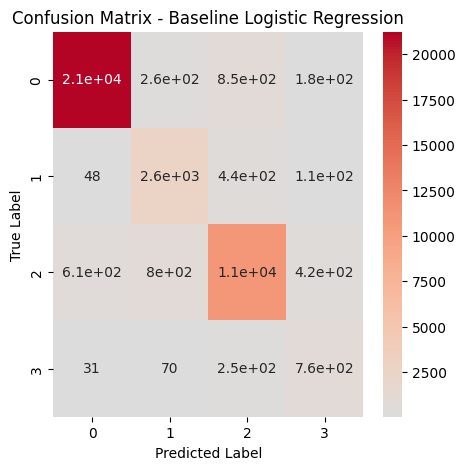

array([0, 2, 2, ..., 0, 2, 2])

In [98]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.linear_model import SGDClassifier

# SGDClassifier is much faster for large datasets
sgd_params = {
    'alpha': [1e-5, 1e-4, 1e-3],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'eta0': [0.01, 0.1],
    'max_iter': [2000, 3000]
}
rs_sgd = RandomizedSearchCV(
    SGDClassifier(
        loss='log_loss',
        learning_rate='optimal',
        class_weight=weight_dict,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ),
    param_distributions=sgd_params,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
) # log_loss = logistic regression


rs_sgd.fit(x_train_final, y_train)

evaluate('Tuned sgd Logistic',
         rs_sgd.best_estimator_,
         x_train_final, x_val_final,
         y_train, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Val Accuracy  : 0.9058
 Macro F1    : 0.8104
Per-class F1 : [0.95598022 0.7822104  0.87785572 0.62556515]
classification_report
               precision    recall  f1-score   support

           0       0.97      0.94      0.96     22534
           1       0.75      0.82      0.78      3219
           2       0.88      0.88      0.88     12738
           3       0.57      0.69      0.63      1109

    accuracy                           0.91     39600
   macro avg       0.79      0.83      0.81     39600
weighted avg       0.91      0.91      0.91     39600



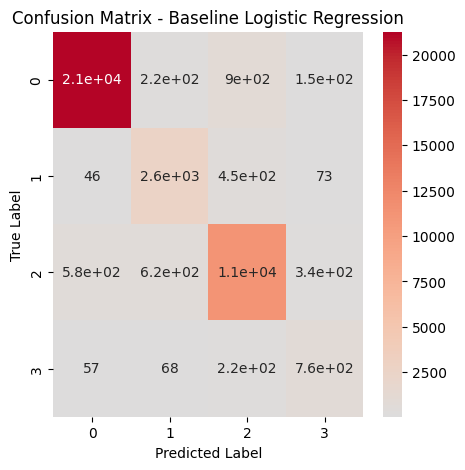

array([0, 2, 2, ..., 0, 2, 2])

In [99]:
from sklearn.svm import LinearSVC

evaluate('Linear SVM', LinearSVC(C=1.0,class_weight=weight_dict # ↑ boost class 3
),x_train_final, x_val_final,
y_train, y_val)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Val Accuracy  : 0.8888
 Macro F1    : 0.7818
Per-class F1 : [0.95159712 0.7412216  0.84481864 0.58960499]
classification_report
               precision    recall  f1-score   support

           0       0.95      0.95      0.95     22534
           1       0.71      0.78      0.74      3219
           2       0.86      0.83      0.84     12738
           3       0.55      0.64      0.59      1109

    accuracy                           0.89     39600
   macro avg       0.77      0.80      0.78     39600
weighted avg       0.89      0.89      0.89     39600



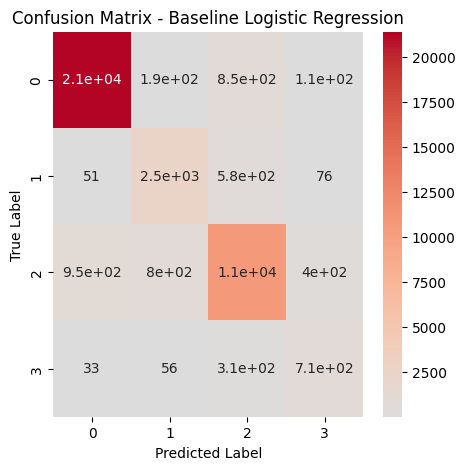

array([0, 2, 2, ..., 0, 2, 2])

In [100]:
sgd_params = {
    'alpha': [1e-5, 1e-4, 1e-3],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'eta0': [0.01, 0.1],
    'max_iter': [2000, 3000]
}

rs_sgd = RandomizedSearchCV(
    SGDClassifier(
        loss='hinge',
        learning_rate='optimal',
        class_weight=weight_dict,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ),
    param_distributions=sgd_params,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
) # hinge = linear svm


rs_sgd.fit(x_train_final, y_train)

evaluate('Tuned sgd linearsvm',
         rs_sgd.best_estimator_,
         x_train_final, x_val_final,
         y_train, y_val)

In [101]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


Val Accuracy  : 0.9075
 Macro F1    : 0.7843
Per-class F1 : [0.96033675 0.77354582 0.87571445 0.52771363]
classification_report
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     22534
           1       0.79      0.75      0.77      3219
           2       0.84      0.92      0.88     12738
           3       0.73      0.41      0.53      1109

    accuracy                           0.91     39600
   macro avg       0.83      0.76      0.78     39600
weighted avg       0.91      0.91      0.91     39600



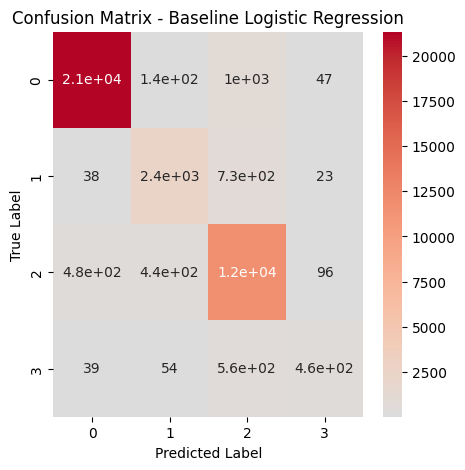

array([0, 2, 2, ..., 0, 2, 2])

In [102]:
from xgboost import XGBClassifier

evaluate('XGBoost', XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist'),x_train_final, x_val_final,
y_train, y_val)

In [103]:
'''!git clone --recursive https://github.com/microsoft/LightGBM
!cd LightGBM && mkdir build && cd build && cmake -DUSE_GPU=1 .. && make -j4
!cd LightGBM/python-package && python setup.py install --precompile   '''

'!git clone --recursive https://github.com/microsoft/LightGBM\n!cd LightGBM && mkdir build && cd build && cmake -DUSE_GPU=1 .. && make -j4\n!cd LightGBM/python-package && python setup.py install --precompile   '

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 38.197144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2617603
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 24067
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Val Accuracy  : 0.9112
 Macro F1    : 0.8207
Per-class F1 : [0.96060038 0.78441558 0.88370644 0.65387894]
classification_report
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     22534
           1       0.73      0.84      0.78      3219
           2       0.88      0.89      0.88     12738
           3       0.62      0.69      0.65      1109

    accuracy                           0.91     39600
   macro avg       0.80      0.84      0.82     39600
weighted avg       0.92      0.91      0.91     39600



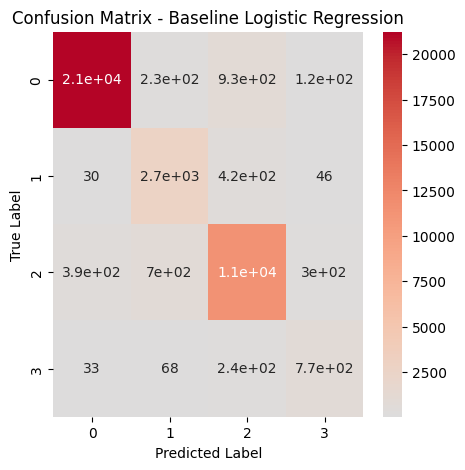

array([0, 2, 2, ..., 0, 2, 2])

In [104]:
from lightgbm import LGBMClassifier
evaluate('LightGBM', LGBMClassifier(
    n_estimators=500, learning_rate=0.05,
    num_leaves=63, class_weight=weight_dict, #or is_unbalance=True
    random_state=42
), x_train_final, x_val_final, y_train, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Val Accuracy  : 0.9073
 Macro F1    : 0.8115
Per-class F1 : [0.96055548 0.77919501 0.87844715 0.62795199]
classification_report
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     22534
           1       0.72      0.85      0.78      3219
           2       0.88      0.87      0.88     12738
           3       0.55      0.73      0.63      1109

    accuracy                           0.91     39600
   macro avg       0.78      0.85      0.81     39600
weighted avg       0.92      0.91      0.91     39600



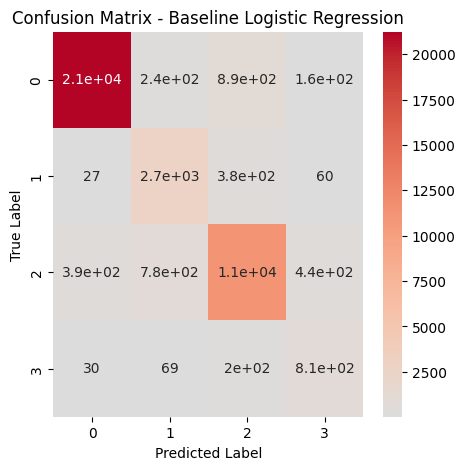

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Val Accuracy  : 0.9126
 Macro F1    : 0.8207
Per-class F1 : [0.96098906 0.7887365  0.88569992 0.64739884]
classification_report
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     22534
           1       0.74      0.84      0.79      3219
           2       0.87      0.90      0.89     12738
           3       0.64      0.66      0.65      1109

    accuracy                           0.91     39600
   macro avg       0.81      0.83      0.82     39600
weighted avg       0.92      0.91      0.91     39600



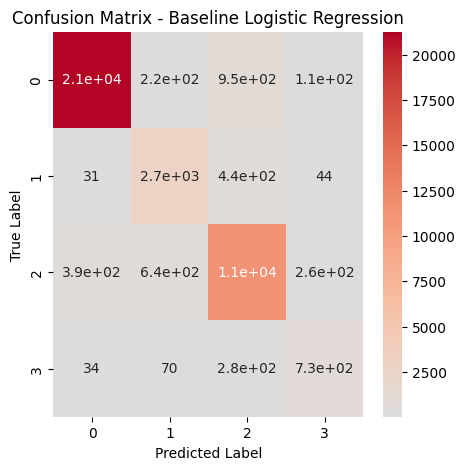

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Val Accuracy  : 0.9001
 Macro F1    : 0.7972
Per-class F1 : [0.95982809 0.77208529 0.86790019 0.58899021]
classification_report
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     22534
           1       0.70      0.87      0.77      3219
           2       0.89      0.85      0.87     12738
           3       0.47      0.79      0.59      1109

    accuracy                           0.90     39600
   macro avg       0.76      0.86      0.80     39600
weighted avg       0.91      0.90      0.90     39600



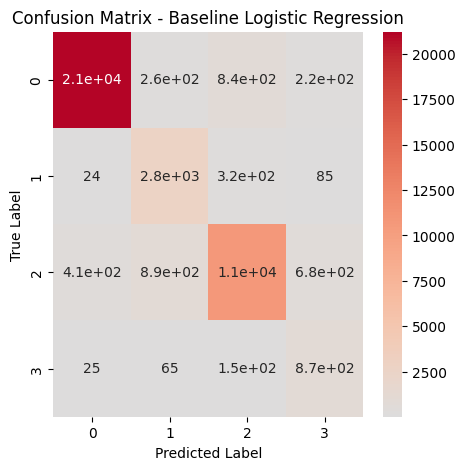

In [105]:
for config in [
    {'num_leaves': 63,  'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'num_leaves': 127, 'min_child_samples': 10, 'subsample': 0.7, 'colsample_bytree': 0.7},
    {'num_leaves': 31,  'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.7},
]:
    evaluate(
        f"LGBM_nl{config['num_leaves']}",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            class_weight=weight_dict,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
            **config
        ),
        x_train_final, x_val_final, y_train, y_val
    )

In [106]:
results

{'Logistic Regression': {'accuracy': 0.7872727272727272,
  'f1_macro': 0.6204562120023785,
  'f1_weighted': 0.8069081655889546,
  'model': LogisticRegression(class_weight='balanced', max_iter=200, n_jobs=-1,
                     random_state=42, solver='saga', tol=0.01)},
 'Tuned sgd Logistic': {'accuracy': 0.897550505050505,
  'f1_macro': 0.7914298378177612,
  'f1_weighted': 0.9002142574125475,
  'model': SGDClassifier(alpha=1e-05,
                class_weight={0: np.float64(0.4321304248191272),
                              1: np.float64(3.118355776045358),
                              2: np.float64(0.7967486217858436),
                              3: np.float64(9.082568807339449)},
                early_stopping=True, eta0=0.1, loss='log_loss', max_iter=2000,
                penalty='elasticnet', random_state=42)},
 'Linear SVM': {'accuracy': 0.9058080808080808,
  'f1_macro': 0.8104028697445843,
  'f1_weighted': 0.9074714978807021,
  'model': LinearSVC(class_weight={0: np.float64(

In [107]:
#model comparasion
cmp=pd.DataFrame({'Model':list(results.keys()),
                   'Accuracy':[v['accuracy'] for v in results.values()],
                   'F1 Macro':[v['f1_macro'] for v in results.values()],
                   'F1 Weighted':[v['f1_weighted'] for v in results.values()]
                  }).sort_values('F1 Macro',ascending=False).reset_index(drop=True)

print(cmp)

                 Model  Accuracy  F1 Macro  F1 Weighted
0           LGBM_nl127  0.912601  0.820706     0.913987
1             LightGBM  0.911162  0.820650     0.912955
2            LGBM_nl63  0.907273  0.811537     0.910087
3           Linear SVM  0.905808  0.810403     0.907471
4            LGBM_nl31  0.900051  0.797201     0.904611
5   Tuned sgd Logistic  0.897551  0.791430     0.900214
6              XGBoost  0.907475  0.784328     0.905817
7  Tuned sgd linearsvm  0.888813  0.781811     0.890011
8  Logistic Regression  0.787273  0.620456     0.806908


In [108]:
best_model_name = max(results, key=lambda k: results[k]['f1_macro'])
best_model = results[best_model_name]['model']

In [109]:
# After finding best model, retrain on full data
x_full_num = preprocessor.transform(x)
x_full_w   = tfidf_w.transform(x['clean_comment'])
x_full_c   = tfidf_c.transform(x['clean_comment'])
x_full_text = hstack([x_full_w, x_full_c])
x_full_final = hstack([x_full_num, x_full_text])

best_model.fit(x_full_final, y)
test_pred = best_model.predict(test_final)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


In [110]:
#test_pred = best_model.predict(test_final)

In [111]:
test_final.shape

(102000, 24067)

In [112]:
test_pred.shape

(102000,)

In [113]:
'''from sklearn.preprocessing import LabelEncoder

cat_col=['if_1','if_2']
encoders={}

for col in cat_col:
    le=LabelEncoder()
    # Fit on combined train+test to ensure same encoding
    combined=pd.concat([train_p[col],test_p[col]])
    le.fit(combined)
    
    train_p[f'{col}_encoded'] = le.transform(train_p[col])
    test_p[f'{col}_encoded'] = le.transform(test_p[col])
    encoders[col] = le

    print(f"Original values in {col}: {train_p[col].unique()}")
    print(f"Encoded values in {col}: {train_p[f'{col}_encoded'].unique()}")'''


'from sklearn.preprocessing import LabelEncoder\n\ncat_col=[\'if_1\',\'if_2\']\nencoders={}\n\nfor col in cat_col:\n    le=LabelEncoder()\n    # Fit on combined train+test to ensure same encoding\n    combined=pd.concat([train_p[col],test_p[col]])\n    le.fit(combined)\n    \n    train_p[f\'{col}_encoded\'] = le.transform(train_p[col])\n    test_p[f\'{col}_encoded\'] = le.transform(test_p[col])\n    encoders[col] = le\n\n    print(f"Original values in {col}: {train_p[col].unique()}")\n    print(f"Encoded values in {col}: {train_p[f\'{col}_encoded\'].unique()}")'

In [114]:
'''
grid_sgd = GridSearchCV(sgd, sgd_params, cv=3, n_jobs=-1, verbose=2)
grid_sgd.fit(x_train_final, y_train)

print("Best parameters:", grid_sgd.best_params_)
best_lr = grid_sgd.best_estimator_
print(best_lr)

y_val_pred = model_lr.predict(x_val_final)
'''



'\ngrid_sgd = GridSearchCV(sgd, sgd_params, cv=3, n_jobs=-1, verbose=2)\ngrid_sgd.fit(x_train_final, y_train)\n\nprint("Best parameters:", grid_sgd.best_params_)\nbest_lr = grid_sgd.best_estimator_\nprint(best_lr)\n\ny_val_pred = model_lr.predict(x_val_final)\n'

In [115]:
#creating submission file
sample=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
print(sample.shape)


(102000, 2)


In [116]:
submission=sample.copy()
submission['label']=test_pred
submission.shape

(102000, 2)

In [117]:
print("test_final shape:", test_final.shape)
print("sample shape:", sample.shape)
print("pred shape:", test_pred.shape)

test_final shape: (102000, 24067)
sample shape: (102000, 2)
pred shape: (102000,)


In [118]:
submission.isna().sum()

ID       0
label    0
dtype: int64

In [119]:
submission.to_csv('submission.csv', index=False)


print ("saved sucessfully")

saved sucessfully
